# Lesson 2: EDA. Visualization

Date: 14.05.2026\
Author: Andrey Zakharov, HSE\
Extended by: Matvey Bakshuk

**Exploratory Data Analysis (EDA)** is the process of examining a dataset before formal modelling to understand its structure, patterns, and anomalies. It was formalised by statistician John Tukey in the 1970s.

The main goals of EDA:
- **Quality check** — find errors, outliers, duplicates, missing data
- **Understand distributions** — how is each variable spread? Is it normal, skewed, bimodal?
- **Explore relationships** — which variables are correlated? Are there groups?
- **Generate hypotheses** — what should we test formally in the next step?

> EDA is not optional. Skipping it means building models on data you don't understand — and is one of the most common sources of errors in data science projects.

Today we will continue our work with the data of [World Happiness Report](https://worldhappiness.report/data/).

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

## 1. Read the data, test for data quality

Before visualising anything we must reproduce the preprocessing pipeline from Lesson 1: read the data, rename variables, add the region/continent variable, handle name mismatches, and drop missing values. This section follows the same steps — treat it as a warm-up repetition.

In [68]:
happy = pd.read_excel('DataForTable2.1WHR2023.xls')
happy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2199 non-null   object 
 1   year                              2199 non-null   int64  
 2   Life Ladder                       2199 non-null   float64
 3   Log GDP per capita                2179 non-null   float64
 4   Social support                    2186 non-null   float64
 5   Healthy life expectancy at birth  2145 non-null   float64
 6   Freedom to make life choices      2166 non-null   float64
 7   Generosity                        2126 non-null   float64
 8   Perceptions of corruption         2083 non-null   float64
 9   Positive affect                   2175 non-null   float64
 10  Negative affect                   2183 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 189.1+ KB


**Rename columns** to shorter, consistent names and drop variables we won't use.

Note: `'Freedom to make life choices'` → `'freedom'` (unified with Lesson 1 naming).

Give variables shorter names:
- `'Country name'` → `'country'`
- `'Life Ladder'` → `'happiness'`
- `'Log GDP per capita'` → `'log_gdp'`
- `'Social support'` → `'social_support'`
- `'Healthy life expectancy at birth'` → `'life_expectancy'`
- `'Freedom to make life choices'` → `'freedom'`
- `'Perceptions of corruption'` → `'corruption'`

Drop columns `'Positive affect'`, `'Negative affect'`

In [69]:
#Your code here
happy.rename(columns = {'Country name':'country',
                        'Life Ladder':'happiness',
                        'Log GDP per capita':'log_gdp',
                        'Social support':'social_support',
                        'Healthy life expectancy at birth':'life_expectancy',
                        'Freedom to make life choices':'freedom',
                        'Perceptions of corruption':'corruption',
                        'Generosity':'generosity'},
             inplace = True)
happy.drop(columns = ['Positive affect', 'Negative affect'], inplace = True)
happy.columns

Index(['country', 'year', 'happiness', 'log_gdp', 'social_support',
       'life_expectancy', 'freedom', 'generosity', 'corruption'],
      dtype='object')

**Scrape the regions table** from Wikipedia using the UN geoscheme. We use a `User-Agent` header to avoid being blocked by the server — some websites reject requests that look like automated scrapers.

In [70]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_and_territories_by_the_United_Nations_geoscheme'
headers = {'User-Agent': 'Mozilla/5.0'}
html = requests.get(url, headers=headers).content
region = pd.read_html(html)[0]

In [71]:
region.head()

,Country or Area,Geographical subregion,Intermediary region[note 3],Continental region,UNSD M49 Codes
0,Algeria,Northern Africa,—,Africa,012 < 015 < 002 < 001
1,Egypt,Northern Africa,—,Africa,818 < 015 < 002 < 001
2,Libya,Northern Africa,—,Africa,434 < 015 < 002 < 001
3,Morocco,Northern Africa,—,Africa,504 < 015 < 002 < 001
4,Sudan,Northern Africa,—,Africa,729 < 015 < 002 < 001


**Select and rename** the relevant columns: country name, geographical subregion, continental region. We apply `.str.lower()` to all column names first so that subsequent rename keys are case-insensitive.

In [72]:
#Your code here
region.columns = region.columns.str.lower()
region.rename(columns = {'country or area':'country',
                         'geographical subregion':'region',
                         'continental region':'continent'},
              inplace=True)
region = region.iloc[:,[0,1,3]]
region.head()

,country,region,continent
0,Algeria,Northern Africa,Africa
1,Egypt,Northern Africa,Africa
2,Libya,Northern Africa,Africa
3,Morocco,Northern Africa,Africa
4,Sudan,Northern Africa,Africa


**Check for duplicates** in the regions table before merging.

If the same country appears twice in the regions table, a left join would create duplicate rows in our happiness dataset — one for each match. This would silently corrupt all aggregations downstream.

In [73]:
#Your code here
region.duplicated().sum()

np.int64(0)

**Merge the datasets** using a left join on `country`.

We set `country` as the index in both DataFrames so pandas matches on it automatically. Left join: all rows from `happy` are kept; countries not found in `region` get `NaN`.

In [74]:
#Your code here
happy1 = happy.set_index('country').join(region.set_index('country'), how = 'left').reset_index()
happy1.head()

,country,year,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption,region,continent
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,NaN,NaN
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,NaN,NaN
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,NaN,NaN
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,NaN,NaN
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,NaN,NaN


**Test missingness** — specifically, how many countries were not matched to a region.

Missing region data usually means the country name is spelled differently in the two datasets (e.g. 'Bolivia' vs 'Bolivia (Plurinational State of)'). We need to identify and fix these mismatches manually.

In [75]:
#Your code here
happy1.isnull().sum()

country              0
year                 0
happiness            0
log_gdp             20
social_support      13
life_expectancy     54
freedom             33
generosity          73
corruption         116
region             339
continent          339
dtype: int64

Some countries are missing region data — their names are coded differently across datasets. Let's see which countries are unmatched and compare with the region table's naming conventions.

In [76]:
happy1.loc[happy1['region'].isnull(),'country'].unique()

array(['Afghanistan', 'Bolivia', 'Congo (Brazzaville)',
       'Congo (Kinshasa)', 'Czechia', 'Eswatini', 'France',
       'Hong Kong S.A.R. of China', 'Iran', 'Ivory Coast', 'Kosovo',
       'Laos', 'Moldova', 'Myanmar', 'Russia', 'Somaliland region',
       'South Korea', 'Syria', 'Taiwan Province of China', 'Tanzania',
       'Turkiye', 'United Kingdom', 'United States', 'Venezuela',
       'Vietnam'], dtype=object)

In [77]:
region.country.sort_values().unique()

array(['Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola',
       'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia (Plurinational State of)',
       'Bonaire, Sint Eustatius and Saba [Caribbean Netherlands]',
       'Bosnia and Herzegovina', 'Botswana', 'Bouvet Island', 'Brazil',
       'British Indian Ocean Territory', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde [Cape Verde]', 'Cambodia', 'Cameroon', 'Canada',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'China, Hong Kong Special Administrative Region',
       'China, Macao Special Administrative Region', 'Christmas Island',
       'Cocos (Keeling) Islands', 'Colombia', 'Comoros',
       'Congo [Republic 

**Recode country names** to match the Wikipedia table's conventions, then repeat the merge. This is a common real-world problem: official country names vary across data sources (ISO standards, UN names, common English names). There is no automated fix — manual inspection and mapping is required.

In [78]:
region['country'] = region.country.replace({'Bolivia (Plurinational State of)':'Bolivia',
                        'Czechia [Czech Republic]': 'Czechia',
                        'Eswatini [Swaziland]': 'Eswatini',
                        'France [French Republic]':'France',
                        'China, Hong Kong Special Administrative Region': 'Hong Kong S.A.R. of China',
                        'Iran (Islamic Republic of)':'Iran',
                        "Côte d'Ivoire [Ivory Coast]":'Ivory Coast',
                        "Lao People's Democratic Republic":'Laos',
                        'Republic of Moldova':'Moldova',
                        'Myanmar [Burma]':'Myanmar',
                        'Russian Federation':'Russia',
                        'Republic of Korea [South Korea]':'South Korea',
                        'Syrian Arab Republic':'Syria',
                        'United Republic of Tanzania':'Tanzania',
                        'United Kingdom of Great Britain and Northern Ireland':'United Kingdom',
                        'United States of America':'United States',
                        'Venezuela (Bolivarian Republic of)':'Venezuela',
                        'Viet Nam':'Vietnam'})

In [79]:
#Your code here
happy2 = happy.set_index('country').join(region.set_index('country'), how = 'left').reset_index()

After the corrected merge, a few countries still have no region — they are simply absent from the Wikipedia table. We recode them manually using `np.where()` (equivalent to a conditional assignment).

In [80]:
happy2.loc[happy2.region.isnull(),'country'].unique()

array(['Afghanistan', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Kosovo',
       'Somaliland region', 'Taiwan Province of China', 'Turkiye'],
      dtype=object)

In [81]:
happy2['region'] = np.where(happy2.country.isin(['Congo (Brazzaville)', 'Congo (Kinshasa)']), 'Middle Africa', happy2.region)
happy2['region'] = np.where(happy2.country=='Kosovo', 'Eastern Europe', happy2.region)
happy2['region'] = np.where(happy2.country=='Taiwan Province of China', 'Eastern Asia', happy2.region)
happy2['region'] = np.where(happy2.country=='Somaliland region', 'Eastern Africa', happy2.region)

In [82]:
happy2['continent'] = np.where(happy2.country.isin(['Congo (Brazzaville)', 'Congo (Kinshasa)', 'Somaliland region']), 'Africa', happy2.continent)
happy2['continent'] = np.where(happy2.country=='Kosovo', 'Europe', happy2.continent)
happy2['continent'] = np.where(happy2.country=='Taiwan Province of China', 'Asia', happy2.continent)

**Final check and drop remaining missing values.** After all merging and recoding, verify no region/continent values are still missing, then drop any rows with missing numeric variables.

In [83]:
#Your code here
happy2.isnull().sum()

country              0
year                 0
happiness            0
log_gdp             20
social_support      13
life_expectancy     54
freedom             33
generosity          73
corruption         116
region              30
continent           30
dtype: int64

In [84]:
#Your code here
happy2.dropna(inplace = True)
happy2.isnull().sum().sum()

np.int64(0)

## 2. Analysis of variable distributions

Understand each variable individually before looking at relationships. Ask: what is the typical value? How spread out is the data? Is it symmetric or skewed? Are there outliers or unusual gaps?

**Choosing the right chart:**

| Variable type | Chart |
|---------------|-------|
| Continuous, distribution shape | Histogram + KDE |
| Continuous, outliers & quartiles | Boxplot |
| Continuous, distribution + density | Violin plot |
| Categorical, frequencies | Bar chart |
| Categorical, proportions of a whole | Pie chart |

We work with 2022 data throughout this section for clarity (one cross-section).

**Show descriptive statistics first:**

- You can find more about `matplotlib` [here](https://matplotlib.org/stable/users/index.html)
- To learn more about `seaborn` see [here](https://seaborn.pydata.org/tutorial.html)

### Histogram

A **histogram** groups continuous values into equal-width **bins** and counts how many observations fall in each bin. It shows the **shape** of the distribution.

Key parameters:
- `bins` — number of bins. Too few: hides detail. Too many: shows noise. A common heuristic: $\sqrt{n}$ bins, or use Sturges' rule.
- `kde=True` — overlay a **Kernel Density Estimate** (KDE): a smoothed continuous version of the histogram. Useful for spotting bimodality and comparing shapes across groups.

We also add vertical lines for the mean and median — their relative positions immediately reveal the direction of skew.

In [85]:
#Your code here
happy2.describe(include = np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,1936.0,2014.29,4.66,2005.00,2010.75,2014.00,2018.00,2022.00
happiness,1936.0,5.47,1.13,2.18,4.62,5.42,6.29,7.97
log_gdp,1936.0,9.35,1.15,5.53,8.46,9.49,10.31,11.66
social_support,1936.0,0.81,0.12,0.29,0.74,0.84,0.91,0.99
life_expectancy,1936.0,63.19,7.04,6.72,58.65,64.98,68.66,74.47
freedom,1936.0,0.75,0.14,0.26,0.66,0.77,0.86,0.99
generosity,1936.0,0.00,0.16,-0.34,-0.11,-0.02,0.09,0.70
corruption,1936.0,0.75,0.19,0.04,0.69,0.80,0.87,0.98


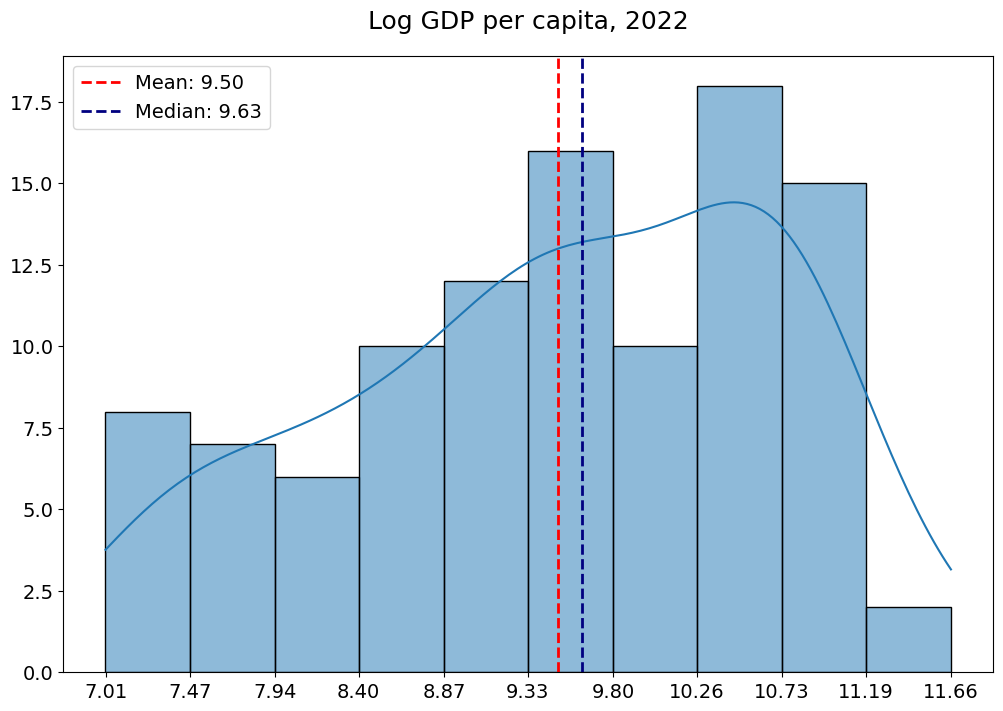

In [86]:
a = happy2[happy2.year==2022]
mean_value = np.mean(a.log_gdp)
median_value = np.median(a.log_gdp)

plt.figure(figsize=(12,8))
ax=sns.histplot(data = a, x = 'log_gdp', bins = 10, kde = True)

plt.tick_params(labelsize=14)
ax.set_xticks(np.round(np.histogram_bin_edges(a.log_gdp, bins=10),2))
ax.axvline(x=mean_value,
           color = 'red', linewidth = 2, linestyle = '--',
           label=f"Mean: {mean_value:.2f}")
ax.axvline(x=median_value,
           color = 'navy', linewidth = 2, linestyle = '--',
           label=f"Median: {median_value:.2f}")
ax.set_title("Log GDP per capita, 2022", fontsize=18, pad = 20)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(fontsize=14, loc = 'upper left')
plt.show()

### Boxplot

A **boxplot** (box-and-whisker plot) summarises a distribution in five numbers: minimum whisker, Q1, median, Q3, maximum whisker. Individual points beyond the whiskers are plotted as dots — potential **outliers**.

Whisker length = 1.5 × IQR from the box edge (the same rule as in Lesson 1 outlier detection). This means boxplots and IQR outlier detection are mathematically equivalent.

**When to prefer boxplot over histogram:** when you want to compare distributions across many groups side-by-side (e.g. happiness by country per year — see §3). A histogram is better for understanding a single distribution in depth.

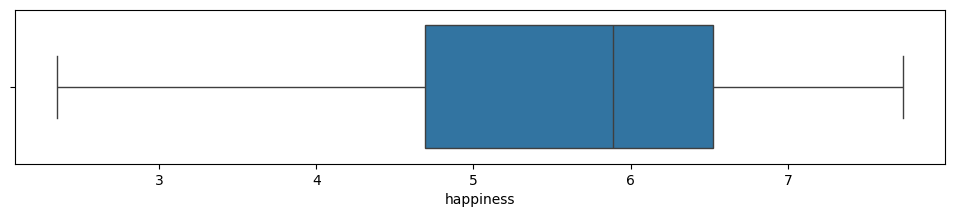

In [87]:
a = happy2[happy2.year==2022]
plt.figure(figsize = (12,2))
sns.boxplot(data = a, x = 'happiness')
plt.show()

What different parts of a boxplot mean:
![](https://cdn1.byjus.com/wp-content/uploads/2020/10/Box-Plot-and-Whisker-Plot-1.png)

### Violin plot

A **violin plot** combines a boxplot with a KDE estimate mirrored on both sides. The width at each y-value is proportional to the density — wider means more observations there.

Compared to a boxplot:
- ✓ Shows **bimodal distributions** (two humps) that a boxplot would hide
- ✓ Shows the full shape of the distribution
- ✗ Harder to read exact quartile values
- ✗ Can be misleading with small samples (the KDE curve smooths over very few points)

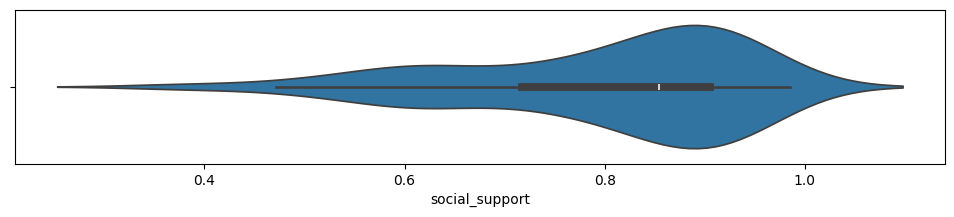

In [88]:
a = happy2[happy2.year==2022]
plt.figure(figsize = (12,2))
sns.violinplot(data = a, x = 'social_support')
plt.show()

What different parts of a violin plot mean:
![](https://api.www.labxchange.org/api/v1/xblocks/lb:LabXchange:46f64d7a:html:1/storage/28__violin-plot-11626365603605-77f9e7acf0e79c553ec92a044b91b6b1.png)

### Bar chart and pie chart — categorical variables

For categorical variables we count (or compute proportions of) observations per category.

**Bar chart** — best for comparing frequencies or proportions across categories. Sorting bars by value makes ranking immediately visible. Horizontal bars work better when category labels are long.

**Pie chart** — shows parts of a whole (proportions must sum to 100%). Effective only with a small number of categories (≤ 5–6). With many slices, small differences are hard to perceive — a sorted bar chart is almost always clearer.

How many countries took part in the survey in 2022, by regions?

In [89]:
#Your code here
a = happy2[happy2.year==2022].region.value_counts(normalize=True).sort_values(ascending = False).round(2)
a

region
Western Africa               0.12
Northern Europe              0.10
Eastern Africa               0.09
South America                0.09
Southern Europe              0.08
Eastern Europe               0.08
Western Europe               0.07
Central America              0.07
Western Asia                 0.05
Middle Africa                0.05
South-eastern Asia           0.04
Southern Asia                0.04
Eastern Asia                 0.03
Central Asia                 0.03
Northern America             0.02
Southern Africa              0.02
Australia and New Zealand    0.02
Caribbean                    0.02
Northern Africa              0.02
Name: proportion, dtype: float64

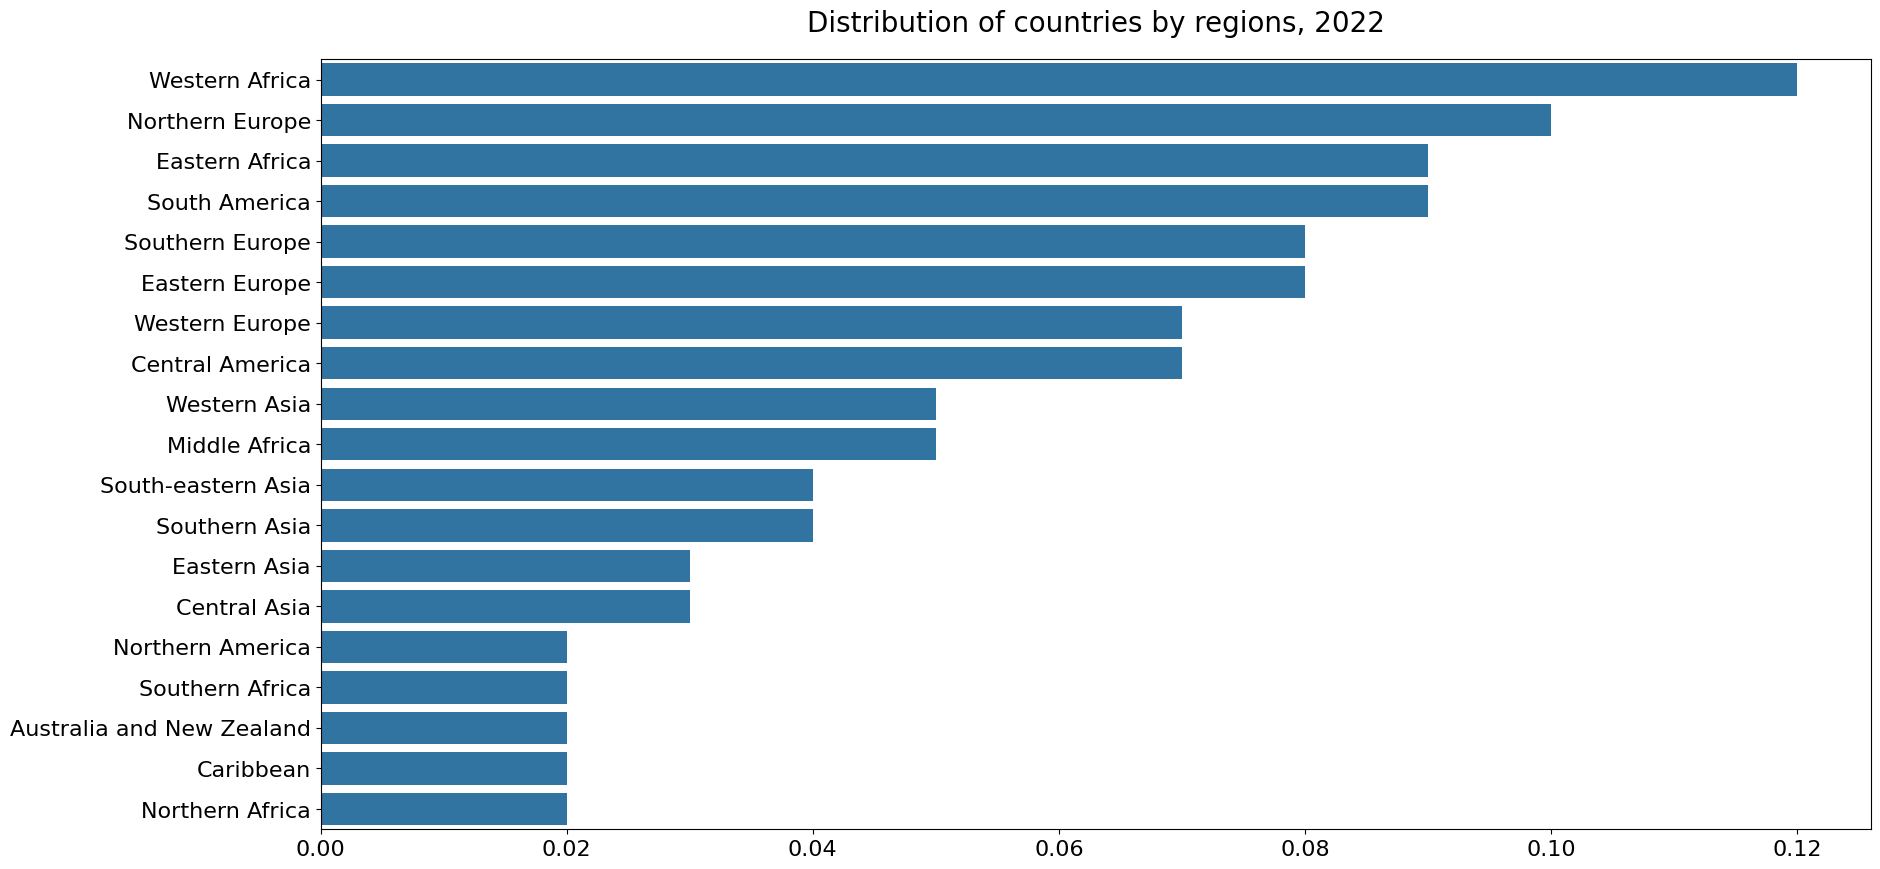

In [90]:
plt.figure(figsize = (20, 10))
ax = sns.barplot(y=a.index, x=a.values)
ax.set_ylabel('')
ax.set_title("Distribution of countries by regions, 2022", fontsize=20, pad=20)
plt.tick_params(labelsize=16)
plt.show()

How many countries countries took part in the survey in 2022, by continents?

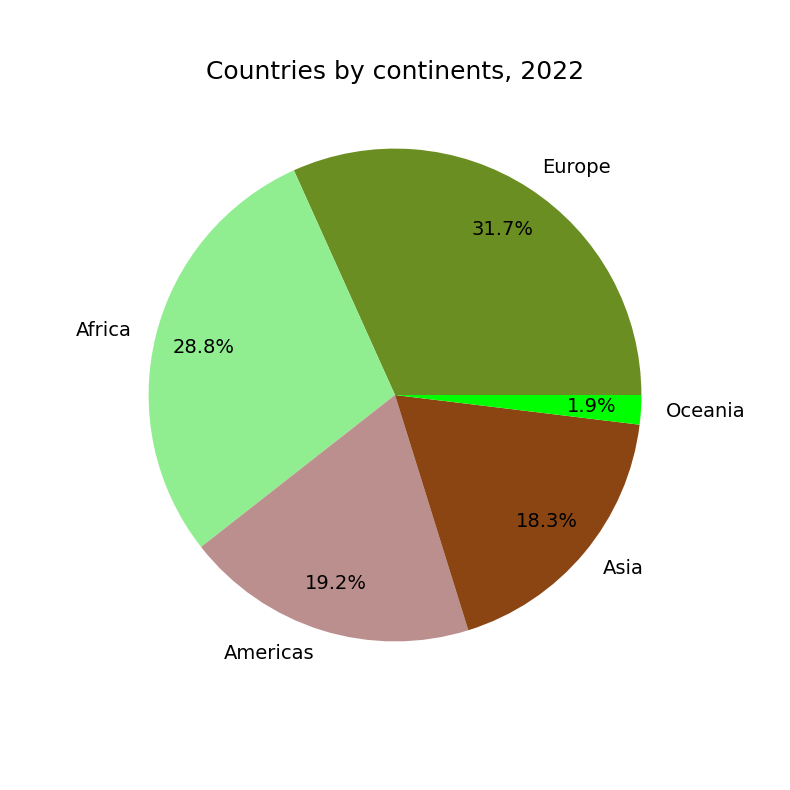

In [91]:
a = happy2[happy2.year==2022].continent.value_counts()
a
plt.figure(figsize = (20, 10))
plt.pie(a,
        labels=a.index,
        autopct='%.1f%%',
        labeldistance=1.1,
        pctdistance=0.8,
        radius = 0.8,
        textprops={'fontsize': 14},
        colors=['olivedrab', 'lightgreen', 'rosybrown', 'saddlebrown', 'lime'])
plt.title("Countries by continents, 2022", fontsize=18, y=.9);

## 3. Analysis of variables relationships

Once you understand each variable individually, look at **how they interact**. Relationships between variables reveal the structure of the data and motivate modelling choices.

This section uses three types of comparisons:
- **Group comparisons** — how does happiness differ across regions and continents?
- **Time series** — how do values change over time?
- **Bivariate relationships** — how are two continuous variables correlated?

### Where are the happiest people?

What is the happiest continent?

In [92]:
#Your code here
pd.pivot_table(happy2[happy2.year==2022],
               index = 'continent',
               values = 'happiness',
               aggfunc='mean').sort_values('happiness', ascending=False)

,happiness
continent,
Oceania,7.004841
Europe,6.472866
Americas,6.270091
Asia,5.292024
Africa,4.297602


What are top-5 happiest regions? Show them in the descending order

In [93]:
#Your code here
happy2[happy2.year==2022].groupby('region')['happiness'].agg(['count','mean']).sort_values('mean', ascending=False).head()

,count,mean
region,,
Northern Europe,10,7.048975
Australia and New Zealand,2,7.004841
Western Europe,7,6.939900
Northern America,2,6.805363
Central America,7,6.437280


**Barplot with confidence intervals.**

When comparing group means, always show **uncertainty**. The error bars here represent 90% bootstrap confidence intervals — if two bars' intervals do not overlap, the difference is likely significant.

seaborn's `sns.barplot` computes these automatically. `errorbar=('ci', 90)` sets the confidence level to 90%.

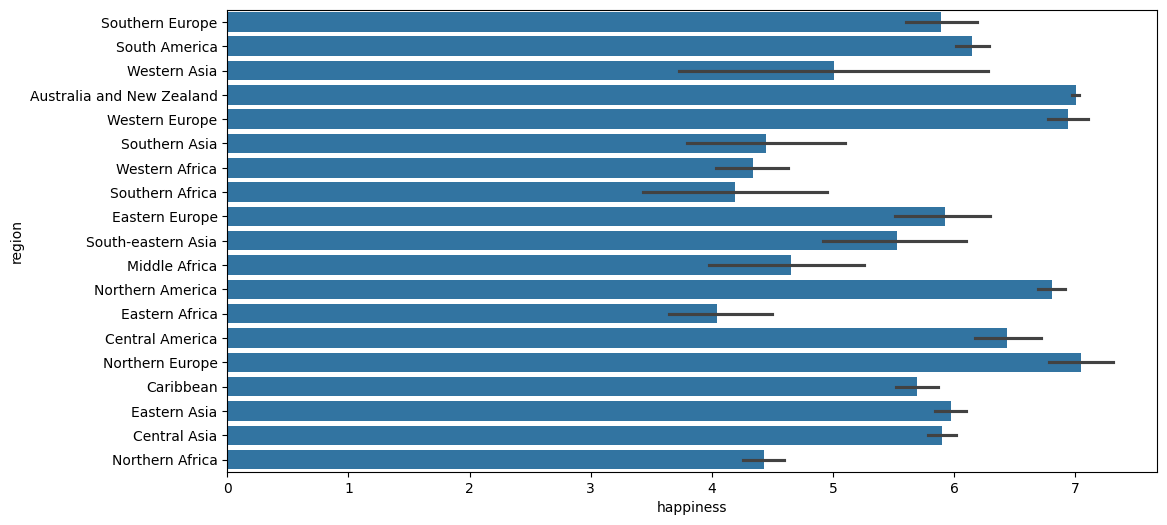

In [94]:
#Your code here
plt.figure(figsize=(12,6))
sns.barplot(data = happy2[happy2.year==2022], x='happiness', y = 'region', errorbar=('ci', 90));

What are the top-10 happiest countries? Show them in descending order

In [95]:
#Your code here
a = pd.pivot_table(happy2[happy2.year==2022], index = 'country', values = 'happiness', aggfunc='mean')\
.sort_values('happiness', ascending=False).head(10)
a

,happiness
country,
Finland,7.728998
Israel,7.662397
Denmark,7.544965
Iceland,7.448794
Sweden,7.431214
Netherlands,7.389636
Norway,7.294604
Luxembourg,7.227935
Costa Rica,7.076658


Make a graph

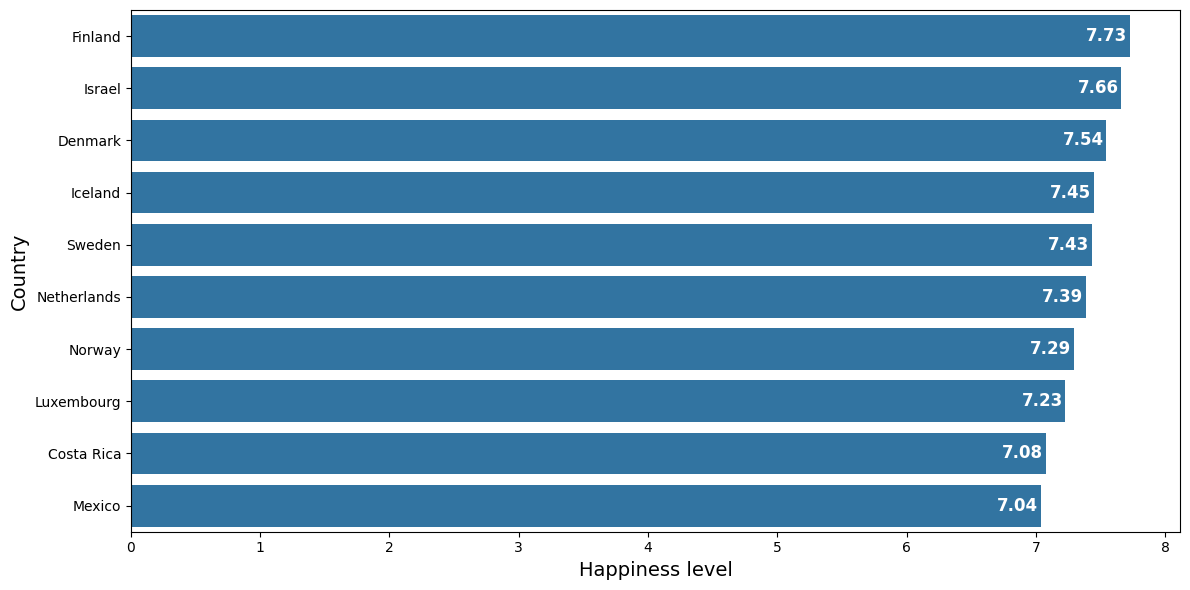

In [96]:
#Your code here
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=a, y='country', x='happiness')

for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.text(width - 0.02, y, f'{width:.2f}',
            ha='right', va='center', color='white', fontsize=12, fontweight='bold')

ax.set_xlabel('Happiness level', fontsize=14)
ax.set_ylabel('Country', fontsize=14)
plt.tight_layout();

### Time series: dynamics of happiness

A **line plot** is the standard choice for time series data — it makes trends, cycles, and structural breaks immediately visible. Connect points with a line only when the x-axis represents **ordered time** (or another ordered variable); for unordered categories a bar chart is more appropriate.

In [97]:
#Your code here
a = happy2.groupby('year')['happiness'].mean().reset_index()
a

,year,happiness
0,2005,7.418048
1,2006,5.192636
2,2007,5.370178
3,2008,5.464791
4,2009,5.467698
5,2010,5.516129
6,2011,5.387117
7,2012,5.426043
8,2013,5.364943
9,2014,5.379817


Let's see the dynamics of happiness in continents.

Using `hue='continent'` and `style='continent'` together encodes group identity with both **colour** and **line style** — making the chart readable in greyscale print too.

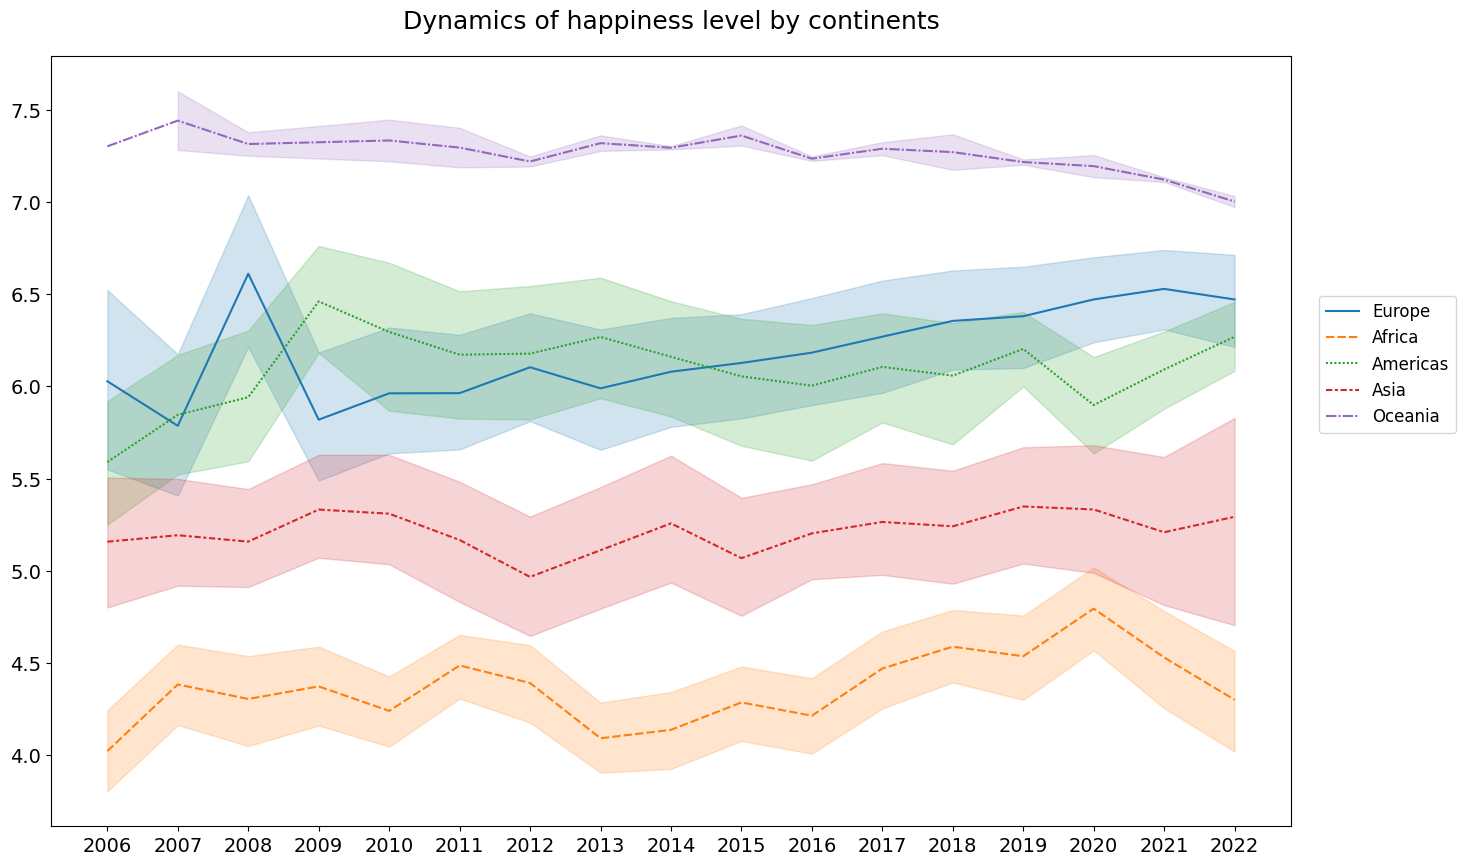

In [98]:
plt.figure(figsize = (16, 10))
ax = sns.lineplot(data = happy2[happy2.year>2005], x = 'year', y = 'happiness',
                  hue = 'continent', style = 'continent')
ax.set_title('Dynamics of happiness level by continents', fontsize = 18, pad = 20)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks(np.arange(2006,2023))
ax.legend(loc='center right',
          bbox_to_anchor=(1.14, 0.6), ncol=1, fontsize=12)
plt.tick_params(labelsize=14)
plt.show()

**Small multiples** (subplots): the same chart type repeated for each group.

When you have many groups and want to see each one clearly without visual clutter, split into a grid of panels. `plt.subplots(nrows, ncols, sharey=True, sharex=True)` creates the grid and **shares the axes** — identical scales make cross-panel comparison accurate.

Here we look at happiness distributions over time for four European sub-regions.

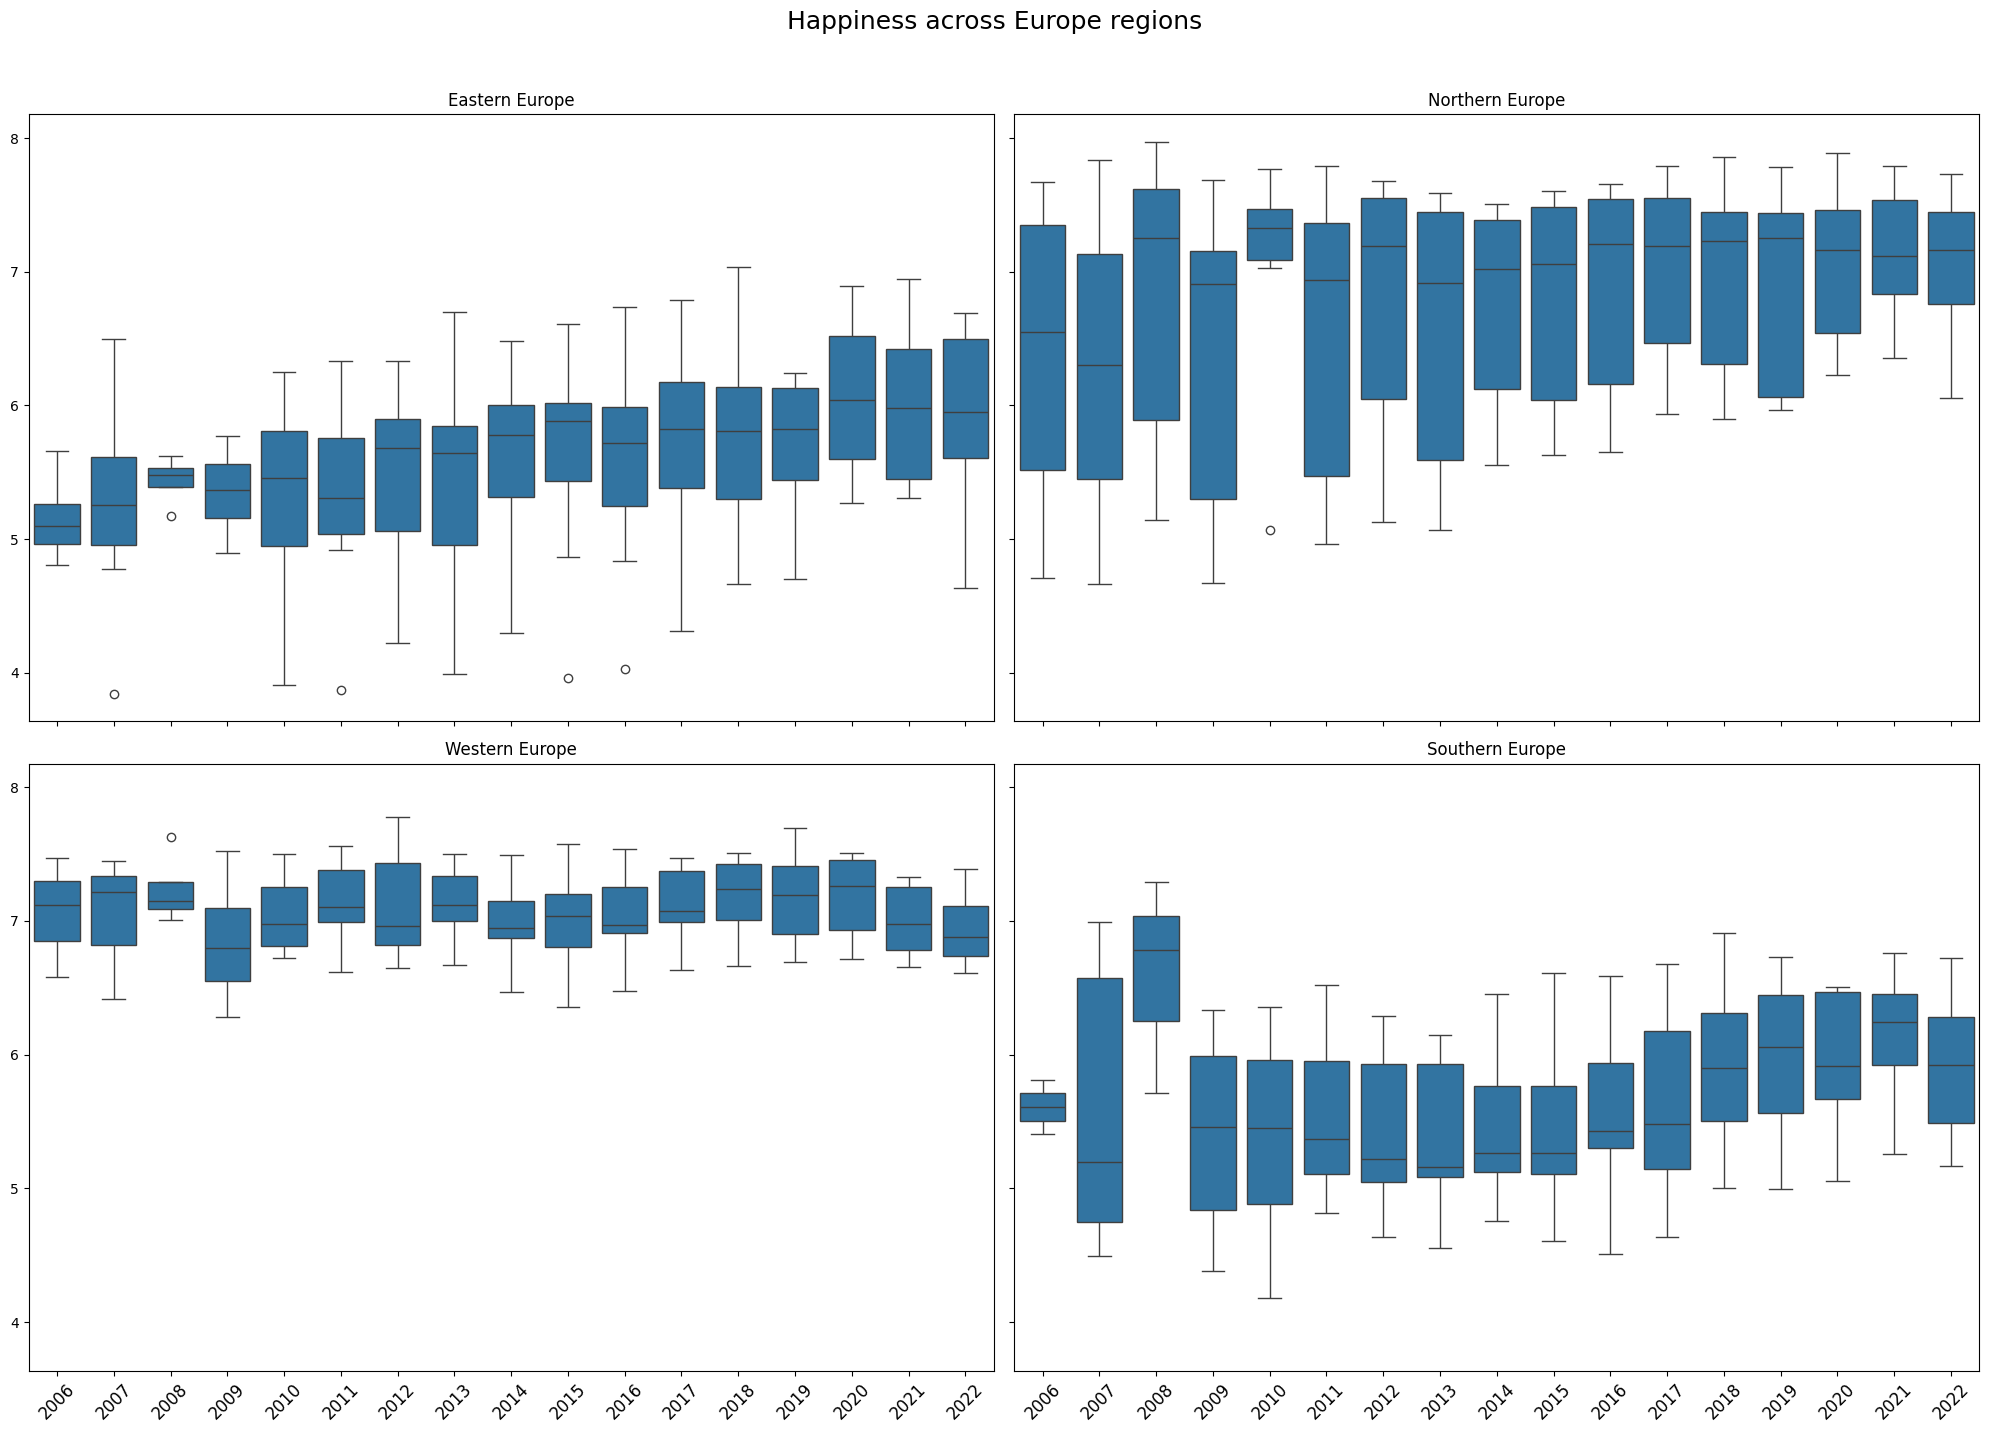

In [99]:
fig,ax = plt.subplots(nrows = 2, ncols = 2, sharey=True, sharex=True, figsize=(20,14))
plt.tick_params(labelsize=12)

sns.boxplot(y='happiness', x="year", data=happy2[happy2.region=='Eastern Europe'], ax=ax[0,0])\
.set(ylabel=None, xlabel=None, title='Eastern Europe')

sns.boxplot(y='happiness', x="year", data=happy2[happy2.region=='Western Europe'], ax=ax[1,0])\
.set(ylabel=None, xlabel=None, title = 'Western Europe')
ax[1,0].tick_params('x', labelsize=12, rotation=45)

sns.boxplot(y='happiness', x="year", data=happy2[happy2.region=='Northern Europe'], ax=ax[0,1])\
.set(ylabel=None, xlabel=None, title = 'Northern Europe')

sns.boxplot(y='happiness', x="year", data=happy2[happy2.region=='Southern Europe'], ax=ax[1,1])\
.set(ylabel=None, xlabel=None, title = 'Southern Europe')
ax[1,1].tick_params('x', labelsize=12, rotation=45)


plt.suptitle('Happiness across Europe regions', y = 1.02, fontsize = 18)
plt.tight_layout()
plt.show()

### Comparing distributions across groups

To compare two continuous distributions, overlay them in a single histogram using `hue`. `alpha < 1` makes bars semi-transparent so overlapping areas are visible. Adding `kde=True` smooths both curves, making shape differences easier to see.

Make a graph: distribution of log GDP per capita in Asia vs Europe (2022).

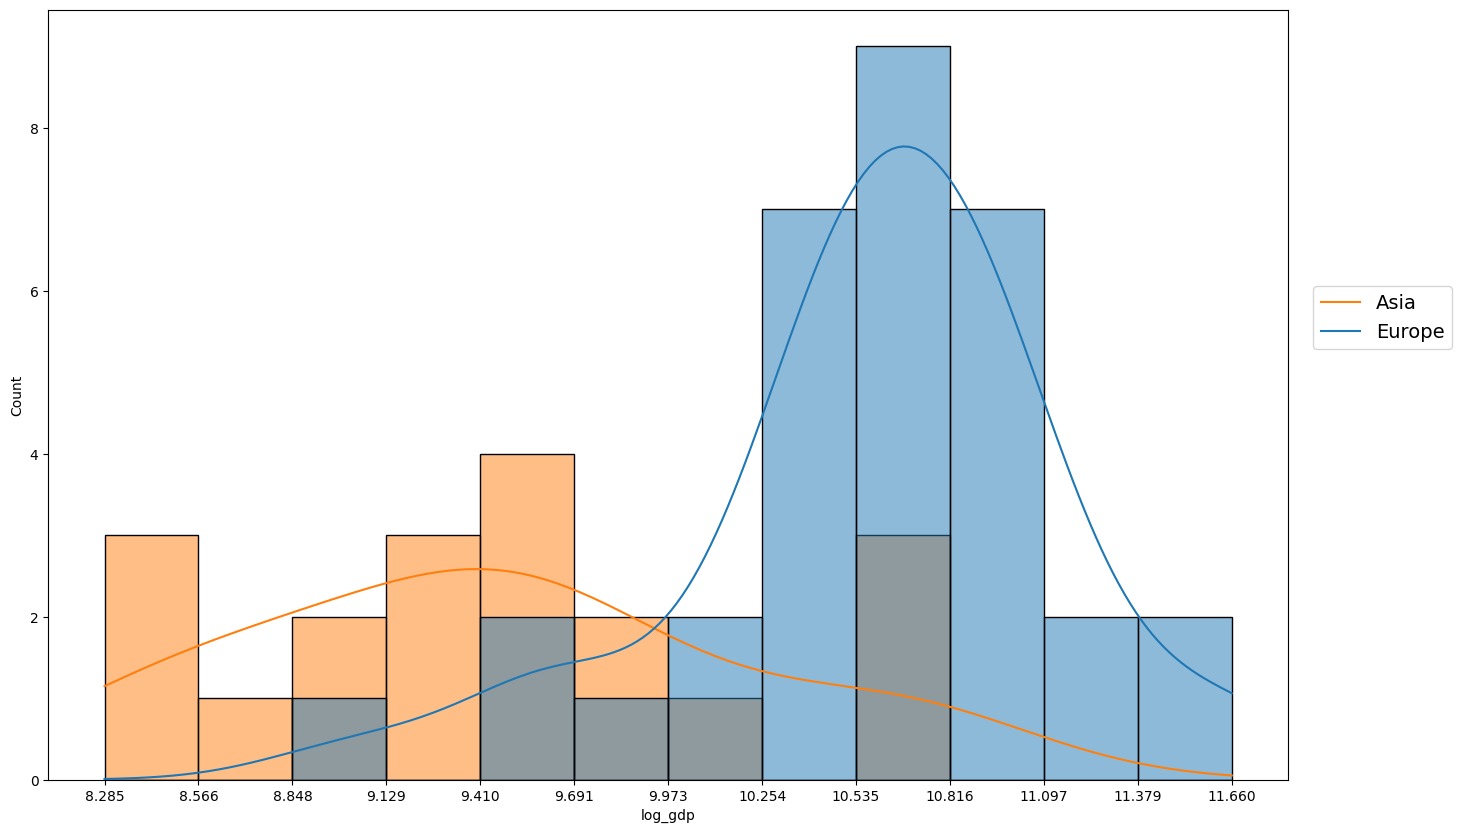

In [100]:
#Your code here
a = happy2[(happy2.continent.isin(['Europe', 'Asia']))&(happy2.year==2022)]
plt.figure(figsize = (16, 10))
ax = sns.histplot(data = a, x = 'log_gdp', hue='continent', alpha = .5, bins = 12, kde = True)
ax.set_xticks(np.histogram_bin_edges(a.log_gdp, bins=12))
ax.legend(['Asia','Europe'], loc='center right',
          bbox_to_anchor=(1.14, 0.6), ncol=1, fontsize = 14);

### Independent samples t-test

A **t-test** tests whether the means of two groups are statistically significantly different.

**Logic:**
- $H_0$ (null hypothesis): $\mu_{Asia} = \mu_{Europe}$ — the population means are equal
- $H_1$ (alternative): $\mu_{Asia} \neq \mu_{Europe}$ — the means differ

The **t-statistic** measures how many standard errors the observed difference is away from zero:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{SE_{diff}}$$

The **p-value** is the probability of observing a difference this large (or larger) if $H_0$ were true. If $p < 0.05$, we reject $H_0$ at the 5% significance level.

We use `equal_var=False` — **Welch's t-test**, which does not assume equal variances in both groups. This is safer than Student's t-test and is the modern default.

Note: distributions do not look normal here, but with $n > 30$ per group the Central Limit Theorem guarantees that the sampling distribution of the mean is approximately normal — so the t-test remains valid.

In [101]:
happy2[happy2.continent.isin(['Asia', 'Europe'])&(happy2.year==2022)].groupby('continent').log_gdp.agg(['count','mean','var'])

,count,mean,var
continent,,,
Asia,19,9.451538,0.549347
Europe,33,10.593119,0.295414


In [102]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(happy2.loc[(happy2.continent=='Asia')&(happy2.year==2022),'log_gdp'],
                                  happy2.loc[(happy2.continent=='Europe')&(happy2.year==2022),'log_gdp'],
                                  equal_var=False)
round(t_stat,3), round(p_value,3)

(np.float64(-5.867), np.float64(0.0))

Average log GDP per capita in Asia (9.45) is lower than in Europe (10.59). The difference is **statistically significant** at $p < 0.01$.

> **Interpretation reminder:** statistical significance $\neq$ practical importance. A tiny difference can be significant with a large sample. Always report the **effect size** alongside the p-value — here the raw difference is ~1.1 log points, which on the original GDP scale corresponds to roughly a 3× difference in GDP per capita.

### One-way ANOVA

When comparing **more than two groups**, a t-test is not appropriate (running multiple t-tests inflates the false positive rate). **ANOVA (Analysis of Variance)** tests whether at least one group mean differs from the others.

- $H_0$: all group means are equal — $\mu_1 = \mu_2 = \mu_3 = \mu_4$
- $H_1$: at least one mean is different

The **F-statistic** is the ratio of between-group variance to within-group variance:

$$F = \frac{\text{variance between group means}}{\text{variance within groups}}$$

A large F (and small p-value) means the groups differ more than you would expect by chance.

> **Important:** ANOVA only tells you *that* at least one group differs — not *which* pairs differ.

Compare log GDP across four European sub-regions:

In [103]:
#Your code here
happy2[(happy2.continent=='Europe')&(happy2.year==2022)].groupby('region').log_gdp.agg(['count','mean','var'])

,count,mean,var
region,,,
Eastern Europe,8,10.122904,0.306000
Northern Europe,10,10.872609,0.115773
Southern Europe,8,10.323252,0.169151
Western Europe,7,11.039657,0.092811


In [104]:
from scipy.stats import f_oneway
f_oneway(happy2.loc[(happy2.region=='Eastern Europe')&(happy2.year==2022),'log_gdp'],
                     happy2.loc[(happy2.region=='Western Europe')&(happy2.year==2022),'log_gdp'],
                     happy2.loc[(happy2.region=='Northern Europe')&(happy2.year==2022),'log_gdp'],
                     happy2.loc[(happy2.region=='Southern Europe')&(happy2.year==2022),'log_gdp'])

F_onewayResult(statistic=np.float64(8.888345033088868), pvalue=np.float64(0.00024697514830545047))

ANOVA results: $F = 8.89$, $p < 0.01$ — log GDP per capita differs significantly across European regions.

This tells us *that* at least one region differs, but not *which* pairs.

### Scatter plot and regression line

A **scatter plot** shows the relationship between two continuous variables. Each point is one observation. You can read off:
- **Direction** — positive or negative association?
- **Strength** — how tightly do points cluster around a trend?
- **Form** — linear, curved, or no pattern?
- **Outliers** — points far from the main cloud

Adding a **regression line** (`sns.regplot`) makes the linear trend explicit. `ci=None` removes the confidence band to keep the chart clean; use `ci=95` to show uncertainty around the line.

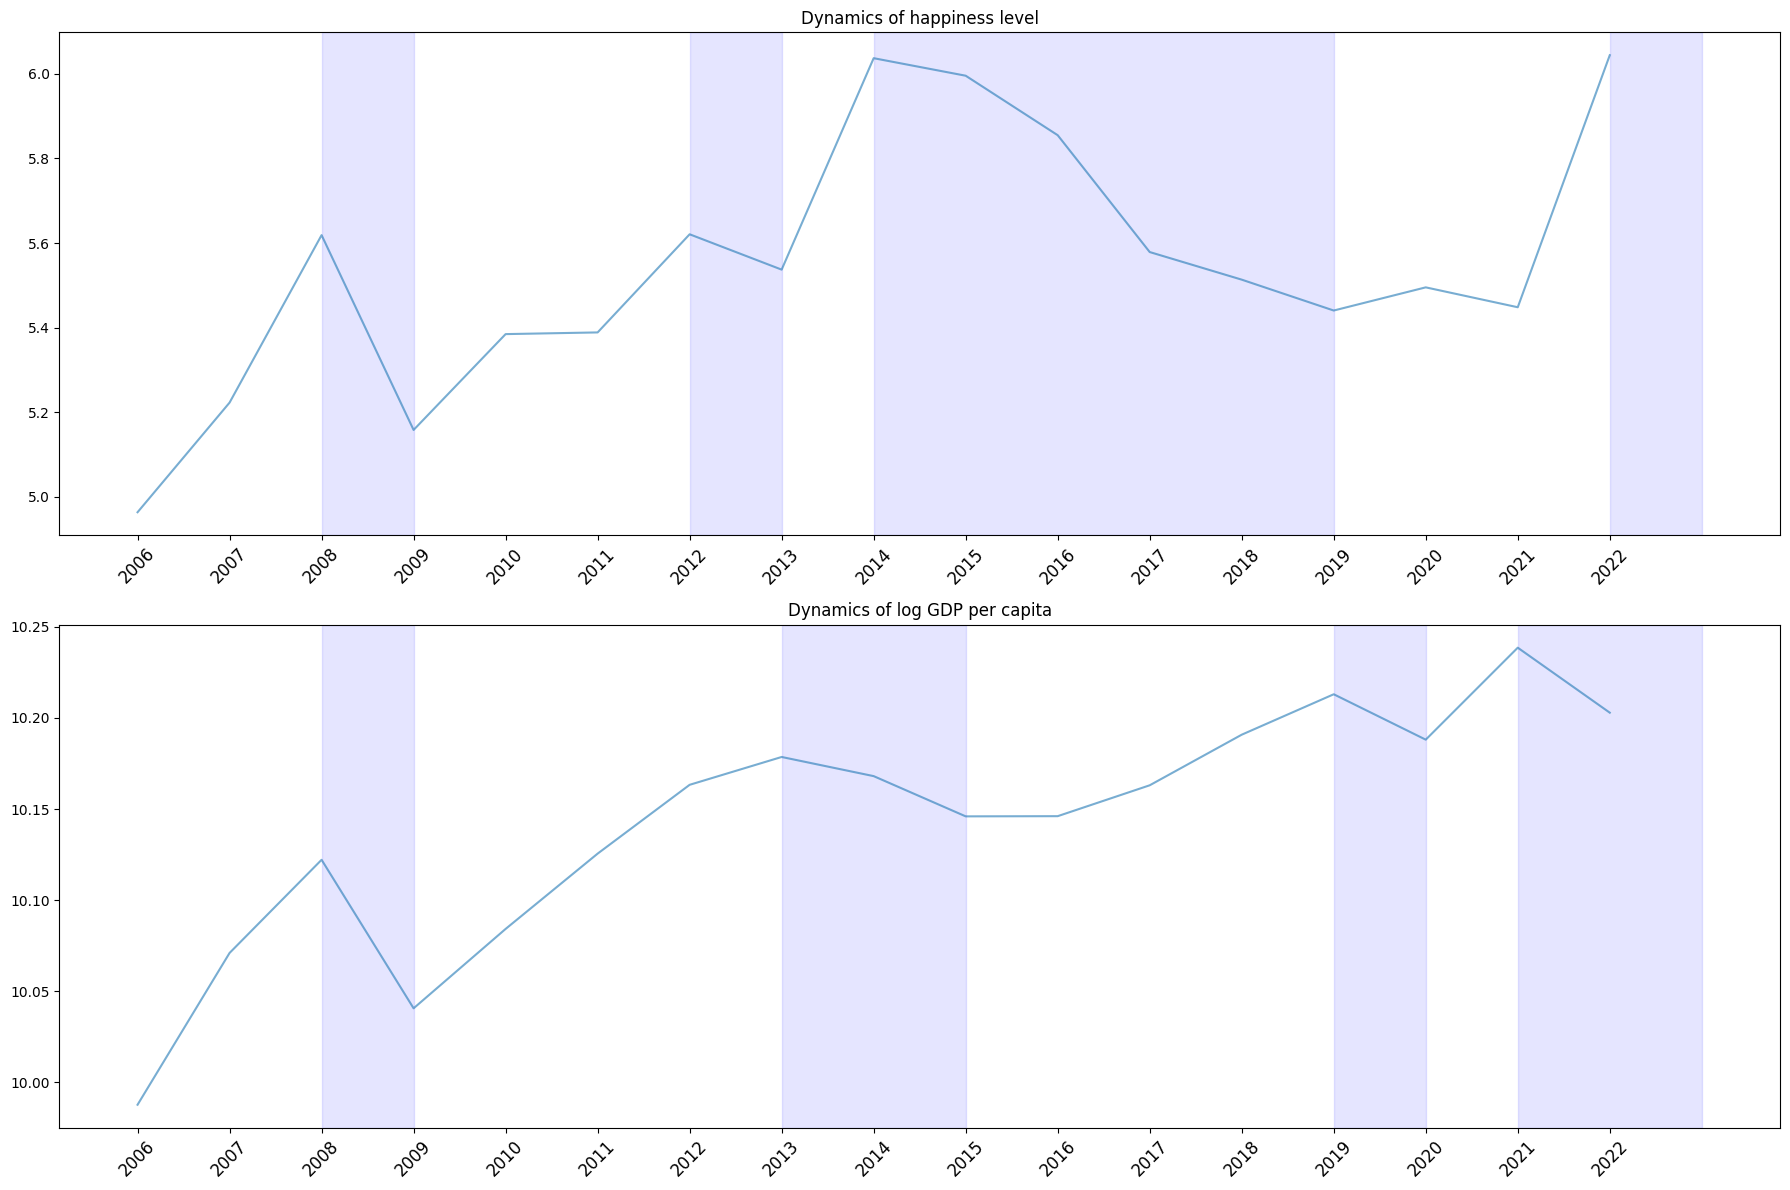

In [105]:
a = happy2[happy2.country=='Russia']
fig,ax = plt.subplots(nrows = 2, figsize=(18,12))

sns.lineplot(x='year', y='happiness', data=a, alpha=0.6, ax=ax[0])
ax[0].set_title('Dynamics of happiness level')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_xticks(list(range(np.min(a.year), np.max(a.year)+1)))
ax[0].tick_params('x', labelsize=12, rotation=45)
ax[0].axvspan(xmin = 2008, xmax= 2009, color = 'blue', alpha = 0.1)
ax[0].axvspan(xmin = 2012, xmax= 2013, color = 'blue', alpha = 0.1)
ax[0].axvspan(xmin = 2014, xmax= 2019, color = 'blue', alpha = 0.1)
ax[0].axvspan(xmin = 2022, xmax= 2023, color = 'blue', alpha = 0.1)

sns.lineplot(x='year', y='log_gdp', data=a, alpha=0.6, ax=ax[1])
ax[1].set_title('Dynamics of log GDP per capita')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_xticks(list(range(np.min(a.year), np.max(a.year)+1)))
ax[1].tick_params('x', labelsize=12, rotation=45)
ax[1].axvspan(xmin = 2008, xmax= 2009, color = 'blue', alpha = 0.1)
ax[1].axvspan(xmin = 2013, xmax= 2015, color = 'blue', alpha = 0.1)
ax[1].axvspan(xmin = 2019, xmax= 2020, color = 'blue', alpha = 0.1)
ax[1].axvspan(xmin = 2021, xmax= 2023, color = 'blue', alpha = 0.1)

plt.tight_layout()
plt.show()

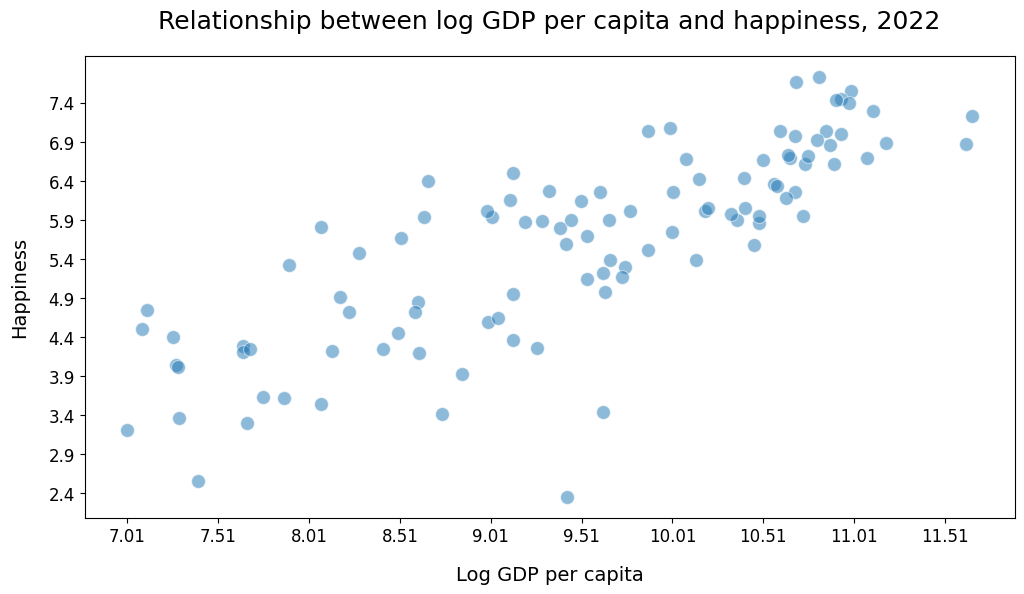

In [106]:
#Your code here
a = happy2[happy2.year==2022]
plt.figure(figsize = (12, 6))
ax = sns.scatterplot(data = a, x = 'log_gdp', y = 'happiness', s=100, alpha = 0.5)
ax.set_title('Relationship between log GDP per capita and happiness, 2022', pad = 20, size=18)
ax.set_ylabel('Happiness', labelpad = 14, size = 14)
ax.set_xlabel('Log GDP per capita', labelpad = 14, size = 14)
ax.set_xticks(np.round(np.arange(np.min(a.log_gdp), np.max(a.log_gdp)+0.1,0.5),2))
ax.set_yticks(np.round(np.arange(np.min(a.happiness), np.max(a.happiness)+0.1,0.5),1))
plt.tick_params(labelsize=12)
plt.show()

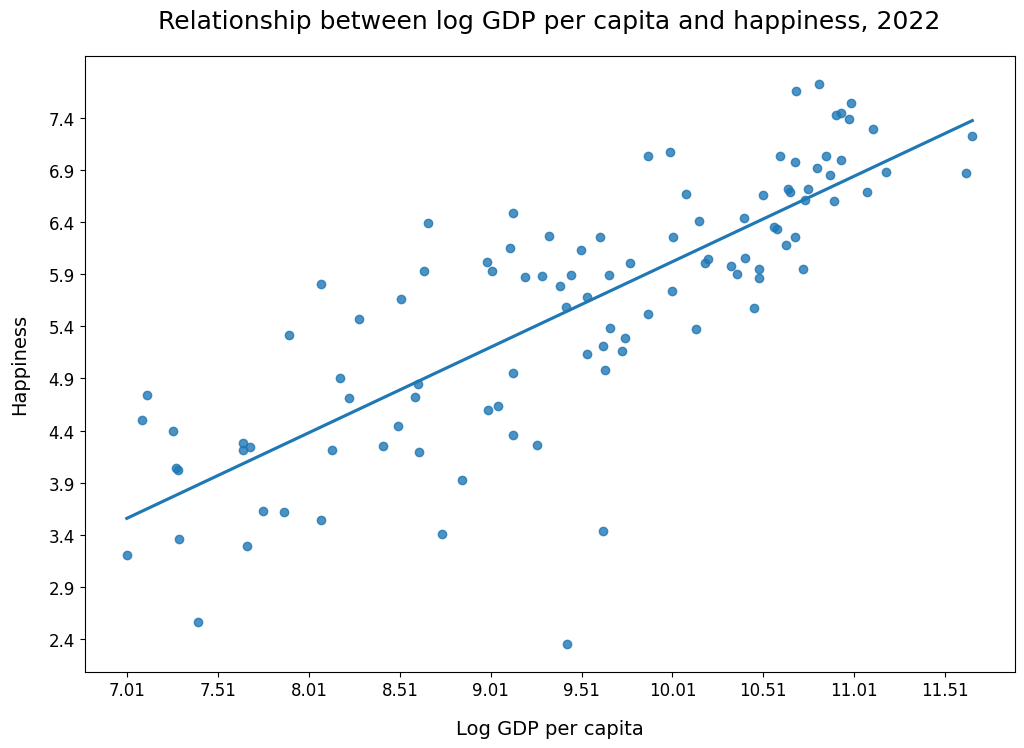

In [107]:
plt.figure(figsize = (12, 8))
ax = sns.regplot(data=happy2[happy2.year==2022], x = 'log_gdp', y = 'happiness', ci=None)
ax.set_title('Relationship between log GDP per capita and happiness, 2022', pad = 20, size=18)
ax.set_ylabel('Happiness', labelpad = 14, size = 14)
ax.set_xlabel('Log GDP per capita', labelpad = 14, size = 14)
ax.set_xticks(np.round(np.arange(np.min(a.log_gdp), np.max(a.log_gdp)+0.1,0.5),2))
ax.set_yticks(np.round(np.arange(np.min(a.happiness), np.max(a.happiness)+0.1,0.5),1))
plt.tick_params(labelsize=12)
plt.show()

From the graphs above we see that log GDP per capita is positively related to happiness — richer countries tend to be happier. However GDP alone does not explain happiness fully: there is considerable scatter around the trend line.

> **Correlation ≠ causation.** The scatter plot shows association, not that wealth *causes* happiness. A third variable (e.g. quality of institutions) could drive both.

### Pairplot and correlation matrix

When you have several numeric variables, examining all pairwise relationships individually is tedious. Two tools speed this up:

**Pairplot** (`sns.pairplot`) — a matrix of scatter plots for every variable pair. The diagonal shows each variable's own distribution. `corner=True` shows only the lower triangle to avoid redundancy.

**Correlation heatmap** — shows Pearson $r$ coefficients as a colour-coded matrix. Useful for quickly spotting the strongest associations.

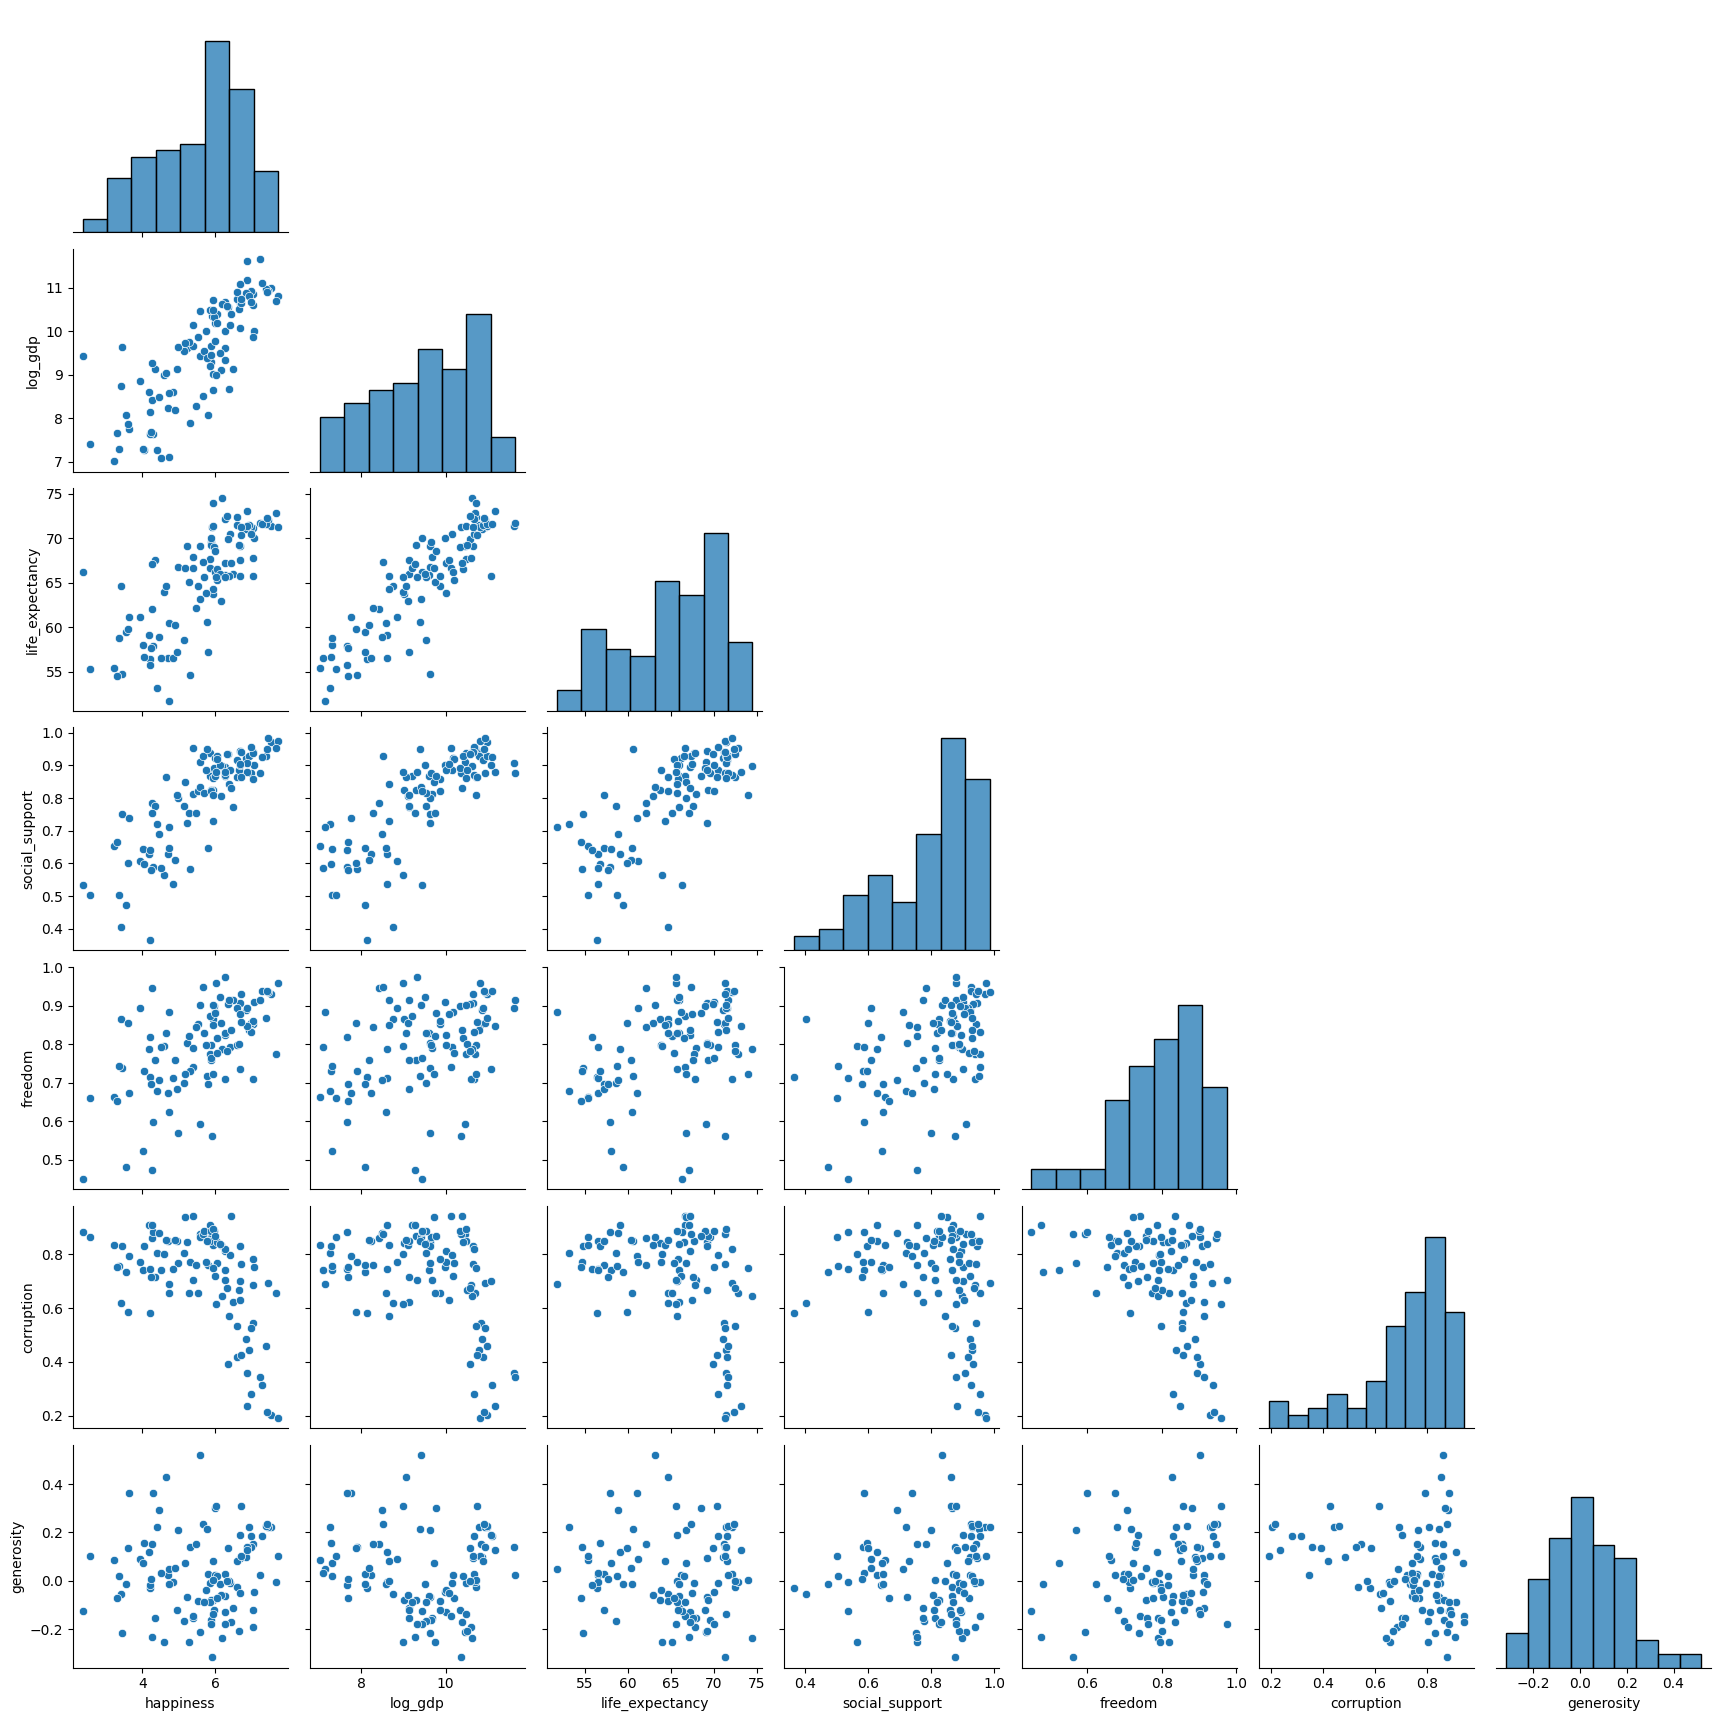

In [108]:
a = happy2.loc[happy2.year==2022, ['happiness', 'log_gdp', 'life_expectancy', 'social_support', 'freedom', 'corruption', 'generosity']]
sns.pairplot(a, corner = True);

**Pearson correlation coefficient** $r$ measures the strength and direction of the **linear** relationship between two variables:

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

| Value of $r$ | Interpretation |
|-------------|----------------|
| $r = +1$ | Perfect positive linear relationship |
| $r = 0$ | No linear relationship |
| $r = -1$ | Perfect negative linear relationship |

> $r$ measures only **linear** associations. Two variables can be strongly related (e.g. in a U-shape) and still have $r \approx 0$.

In [109]:
a

,happiness,log_gdp,life_expectancy,social_support,freedom,corruption,generosity
28,5.212213,9.626483,69.175003,0.724090,0.802250,0.845502,-0.065987
59,6.260993,10.011405,67.250000,0.893330,0.825189,0.810037,-0.127506
75,5.381943,9.667766,67.925003,0.811169,0.789599,0.704730,-0.154325
91,7.034696,10.853529,71.125000,0.941673,0.853777,0.545217,0.153465
106,6.998997,10.938917,71.275002,0.876287,0.855503,0.524212,0.139042
...,...,...,...,...,...,...,...
2087,6.692790,11.078596,65.724998,0.900262,0.735640,0.701128,0.190581
2104,6.670853,10.084121,67.500000,0.904825,0.877969,0.631337,-0.051668
2120,6.016239,8.989866,65.599998,0.878923,0.959019,0.615844,0.308951
2154,6.266509,9.332854,65.599998,0.878744,0.975405,0.703423,-0.178987


In [110]:
corr = a.corr().round(2)

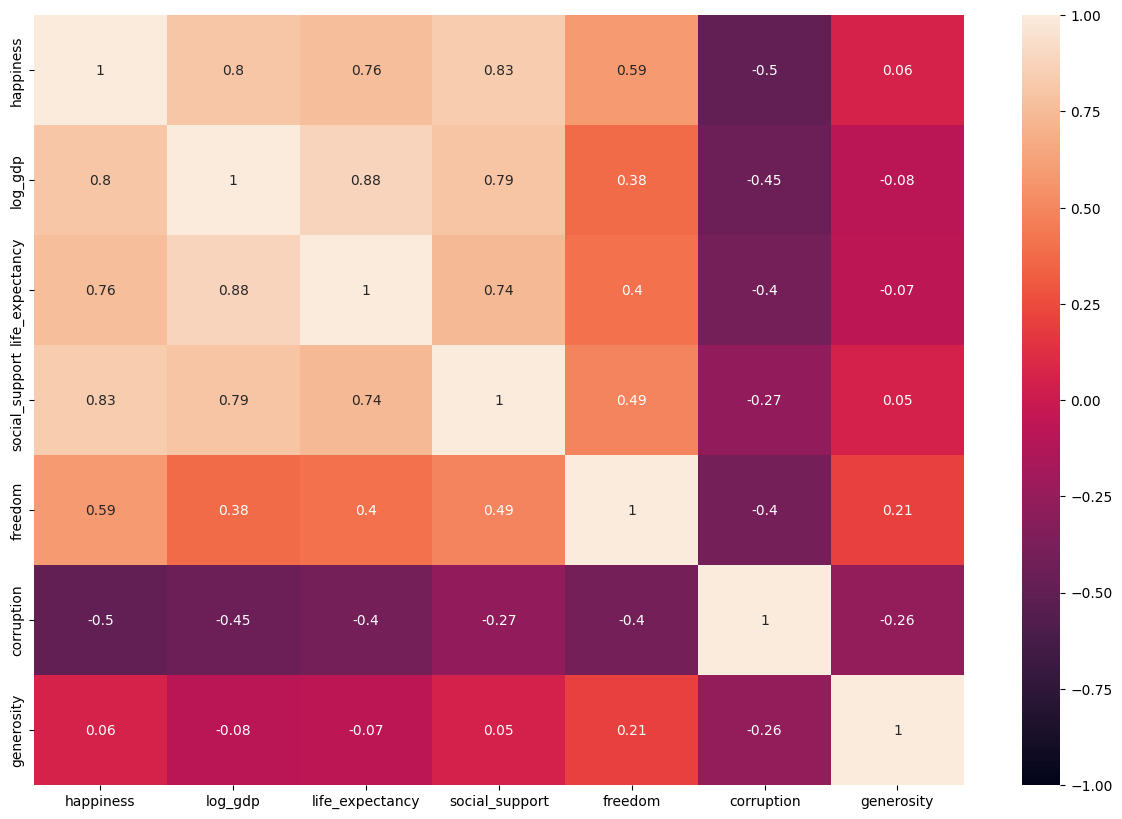

In [111]:
plt.figure(figsize = (15, 10))
sns.heatmap(corr, vmin=-1, vmax = 1, annot=True);

The heatmap shows the magnitude of correlations but not whether they are **statistically significant**. A correlation can look large in a small sample simply by chance.

Below we add significance stars: `*` = $p < 0.05$, `**` = $p < 0.01$. We compute p-values for all pairs using `pearsonr` from `scipy.stats`.

In [112]:
from scipy.stats import pearsonr

rho = a.corr()
pval = a.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [.05, .01] if x<=t]))
rho.round(2).astype(str) + p

,happiness,log_gdp,life_expectancy,social_support,freedom,corruption,generosity
happiness,1.0**,0.8**,0.76**,0.83**,0.59**,-0.5**,0.06
log_gdp,0.8**,1.0**,0.88**,0.79**,0.38**,-0.45**,-0.08
life_expectancy,0.76**,0.88**,1.0**,0.74**,0.4**,-0.4**,-0.07
social_support,0.83**,0.79**,0.74**,1.0**,0.49**,-0.27**,0.05
freedom,0.59**,0.38**,0.4**,0.49**,1.0**,-0.4**,0.21*
corruption,-0.5**,-0.45**,-0.4**,-0.27**,-0.4**,1.0**,-0.26**
generosity,0.06,-0.08,-0.07,0.05,0.21*,-0.26**,1.0**


**FacetGrid — small multiples.**

`sns.FacetGrid` generates a grid of identical plots, one per group (continent here). This lets you see whether the same pattern holds across subgroups — an important check before generalising findings.

First: distribution of corruption by continent (do some continents have lower corruption overall?).
Then: regression of happiness on corruption per continent (does the relationship differ in strength or direction across continents?).

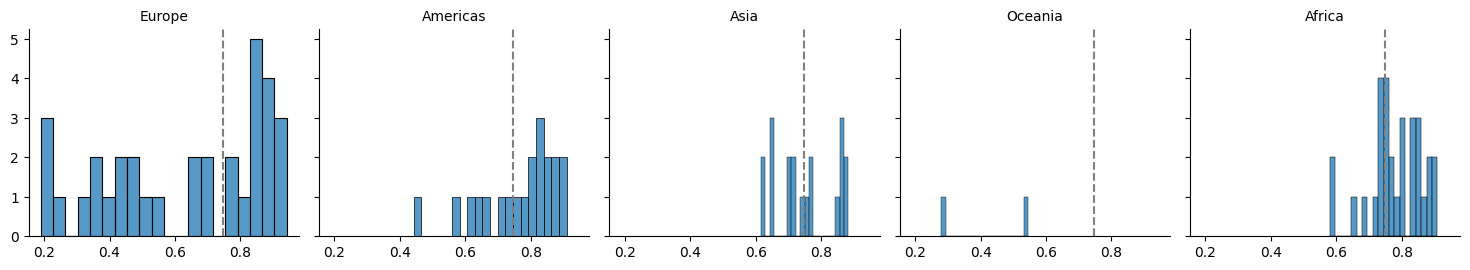

In [113]:
ax = sns.FacetGrid(happy2[happy2.year==2022],
                  col = 'continent',
                  margin_titles=False)
ax.map_dataframe(sns.histplot, 'corruption', bins=20)
ax.refline(x=happy2.corruption.mean())
ax.set_titles(col_template="{col_name}")
ax.set_ylabels('')
ax.set_xlabels('');

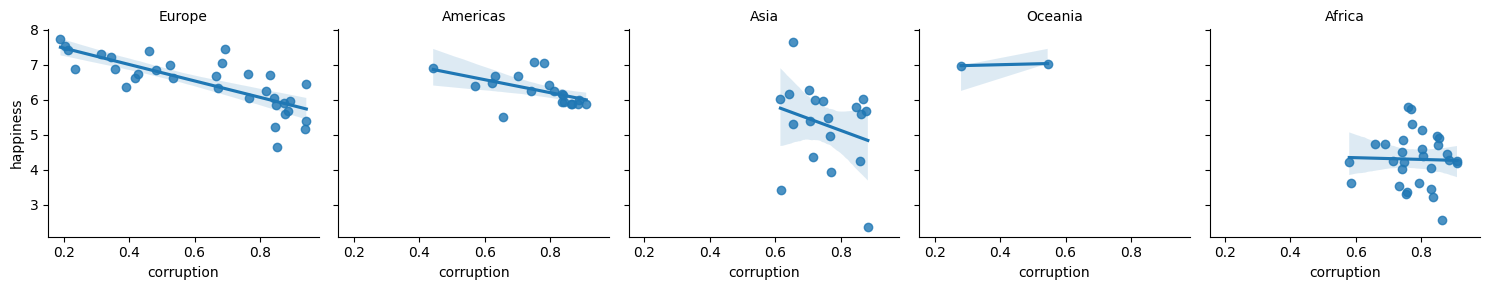

In [114]:
ax = sns.FacetGrid(happy2[happy2.year==2022],
                  col = 'continent',
                  margin_titles=False)
ax.map_dataframe(sns.regplot, 'corruption', 'happiness')
ax.set_titles(col_template="{col_name}");

### 4. Automated EDA

Writing EDA code from scratch is time-consuming. Several libraries generate comprehensive reports automatically:

| Library | Output | Notes |
|---------|--------|-------|
| `ydata-profiling` | Interactive HTML report | Most comprehensive |
| `sweetviz` | HTML comparison report | Great for train/test comparison |
| `dtale` | Live web interface | Good for exploration |

Automated EDA is a useful **starting point**, but it cannot replace domain knowledge. It treats every column independently and does not know that our data is longitudinal (one row = country × year) — so some outputs (e.g. correlations across all years) can be misleading.

See: Oluleye, A. (2023). *Exploratory Data Analysis with Python Cookbook*, Ch.10

In [115]:
# pip install ydata-profiling

In [116]:
from ydata_profiling import ProfileReport
profile = ProfileReport(happy2, title="EDA Report", explorative=True)
profile.to_file("report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 127.26it/s]


> **Caution:** the report above treats all rows as independent observations. In our long-format data, the same country appears ~15 times (once per year). This inflates correlations and makes distribution statistics look more precise than they are. For a valid cross-sectional report, filter to a single year first: `ProfileReport(happy2[happy2.year==2022], ...)`

### 5. Interactive visualisation with Plotly

Static matplotlib/seaborn charts are great for reports and papers. **Interactive charts** are better for exploration and presentations — users can hover over points, zoom, pan, and filter by clicking the legend.

**`plotly.express`** (aliased as `px`) provides a high-level API similar to seaborn: one function call produces a fully interactive chart. Under the hood it uses D3.js and renders in any browser.

Key advantages over static charts:
- **Hover tooltips** — show any column's value for any data point on demand
- **Legend interaction** — click to show/hide groups
- **Zoom & pan** — built-in without extra code
- **Animation** — animate over a variable (e.g. year) with one parameter

You can learn more about plotly [here](https://plotly.com/python/)

In [117]:
import plotly.express as px

# Interactive scatter with regression line per continent
# Hover over any point to see social_support, corruption, life_expectancy
fig = px.scatter(
    happy2[happy2.year == 2022],
    x='log_gdp', y='happiness',
    color='continent',                          # colour by continent
    hover_data=['country', 'social_support', 'corruption', 'life_expectancy'],
    trendline='ols',                            # add OLS regression line per group
    trendline_color_override='red',
    facet_col='continent',                      # one panel per continent
    title='Log GDP per capita vs Happiness by continent, 2022',
    labels={'log_gdp': 'Log GDP per capita', 'happiness': 'Happiness'},
    height=450, width=1400
)
fig.show()

#### Animated scatter plot over time

`animation_frame` steps through values of a variable (here: year), creating a timeline you can play. This is one of the most powerful features of Plotly — a static chart cannot convey temporal dynamics as intuitively.

In [118]:
fig = px.scatter(
    happy2[happy2.year >= 2010],
    x='log_gdp', y='happiness',
    animation_frame='year',               # play button animates over years
    animation_group='country',            # track each country across frames
    color='continent',
    size='life_expectancy',               # bubble size = life expectancy
    size_max=20,
    hover_name='country',
    range_x=[6, 12], range_y=[2, 9],      # fix axes so animation is comparable
    title='GDP vs Happiness over time (bubble size = life expectancy)',
    labels={'log_gdp': 'Log GDP per capita', 'happiness': 'Happiness'},
    height=550
)
fig.show()

#### Interactive bar chart — top-15 happiest countries

Plotly bar charts support the same hover, zoom, and legend interaction. Clicking a continent in the legend hides/shows that group's bars.

In [130]:
top15 = (
    happy2[happy2.year == 2022]
    .sort_values('happiness', ascending=False)
    .head(15)
)

fig = px.bar(
    top15,
    x='happiness', y='country',
    color='continent',
    orientation='h',                       # horizontal bars
    text='happiness',                      # show values on bars
    hover_data=['log_gdp', 'social_support', 'corruption'],
    title='Top-15 happiest countries, 2022',
    labels={'happiness': 'Happiness score', 'country': ''},
    height=500
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='inside')
fig.update_layout(yaxis=dict(autorange='reversed'))
fig.show()

#### Interactive line chart — happiness dynamics by continent

Click on continent names in the legend to isolate individual series. Double-click to isolate one group and hide all others.

In [120]:
dynamics = (
    happy2[happy2.year >= 2006]
    .groupby(['year', 'continent'])['happiness']
    .mean().reset_index()
)

fig = px.line(
    dynamics,
    x='year', y='happiness',
    color='continent',
    markers=True,                          # show dots at each year
    title='Average happiness by continent over time',
    labels={'happiness': 'Mean happiness', 'year': 'Year'},
    height=480
)
fig.show()

#### Choropleth map — happiness world map

A **choropleth** colours geographic regions by a variable value. It gives an instant spatial overview that tables and bar charts cannot match. Plotly uses ISO 3166-1 alpha-3 country codes internally; `locationmode='country names'` lets us use plain country names directly.

In [131]:
fig = px.choropleth(
    happy2[happy2.year == 2022],
    locations='country',
    locationmode='country names',
    color='happiness',
    color_continuous_scale='RdYlGn',       # red=low, green=high
    range_color=[2, 8],
    hover_data=['continent', 'log_gdp', 'social_support'],
    title='World Happiness Score, 2022',
    height=500
)
fig.update_layout(coloraxis_colorbar_title='Happiness')
fig.show()

#### Interactive box plot — happiness distribution by continent

Hover over any point to see the country name. Click a continent to hide it. `points='all'` shows individual observations on top of the box.

In [122]:
fig = px.box(
    happy2[happy2.year == 2022],
    x='continent', y='happiness',
    color='continent',
    points='all',                          # show all individual points
    hover_data=['country'],
    title='Happiness distribution by continent, 2022',
    labels={'happiness': 'Happiness score', 'continent': ''},
    height=500
)
fig.show()

---
# Seminar Assignment

Work independently. Apply the EDA techniques from the lecture to a new dataset.

**Dataset:** `titanic` from seaborn — passenger data from the RMS Titanic (1912). 891 observations, 15 variables including passenger class, age, sex, fare, number of relatives aboard, port of embarkation, and survival status.

Load with: `df = sns.load_dataset('titanic')`

## Task 1. Load and inspect

1. Load the dataset and print `.info()` and `.describe()`.
2. How many passengers survived? Show absolute count and percentage.
3. What are the unique values of `pclass`, `sex`, `embark_town`?

In [139]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Your code here
# 1.1
df = sns.load_dataset('titanic')
display(df.info())
display(df.describe())
display(df.describe(include='object'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [160]:
# 1.2
print(f'Number of people who survived: {df['survived'].sum()}')
#df['survived'].value_counts(normalize=True) # returns a pd.Series object
print(f'Share of people who survived: {df['survived'].value_counts(normalize=True).values[1].round(2)}')
print(f'Percent of people who survived: {(df['survived'].value_counts(normalize=True).values[1]*100).round(2)} %')

Number of people who survived: 342
Share of people who survived: 0.38
Percent of people who survived: 38.38 %


In [189]:
# 1.3
print(f'Unique values of selected columns:')
print(f'pclass: {df['pclass'].unique()}')
print(f'sex: {df['sex'].unique()}')
print(f'embark_town: {df['embark_town'].unique()}')

## Option 2
print('-'*100)
print('Option 2')
print('-'*100)
for col in ['pclass', 'sex', 'embark_town']:
    print(col+":", sorted(df[col].dropna().unique()))

Unique values of selected columns:
pclass: [3 1 2]
sex: ['male' 'female']
embark_town: ['Southampton' 'Cherbourg' 'Queenstown' nan]
----------------------------------------------------------------------------------------------------
Option 2
----------------------------------------------------------------------------------------------------
pclass: [np.int64(1), np.int64(2), np.int64(3)]
sex: ['female', 'male']
embark_town: ['Cherbourg', 'Queenstown', 'Southampton']


['Cherbourg', 'Queenstown', 'Southampton']

In [190]:
sorted(df['embark_town'].dropna().unique())

['Cherbourg', 'Queenstown', 'Southampton']

## Task 2. Distributions of numeric variables

1. Plot a **histogram with KDE** for `age`. Add vertical lines for mean and median. What does the skew tell you?
2. Plot a **histogram** for `fare`. Why is it so heavily skewed?
3. Show **boxplots** for `age` and `fare` side-by-side. Are there outliers? How many standard IQR-based outliers are in `fare`?

In [124]:
# Your code here


## Task 3. Distributions of categorical variables

1. Plot a **bar chart** of passenger counts by `pclass` (sorted descending).
2. Plot a **pie chart** of passengers by `embark_town`.
3. Which class had the highest survival rate? Use `groupby` + `mean()` on `survived`.

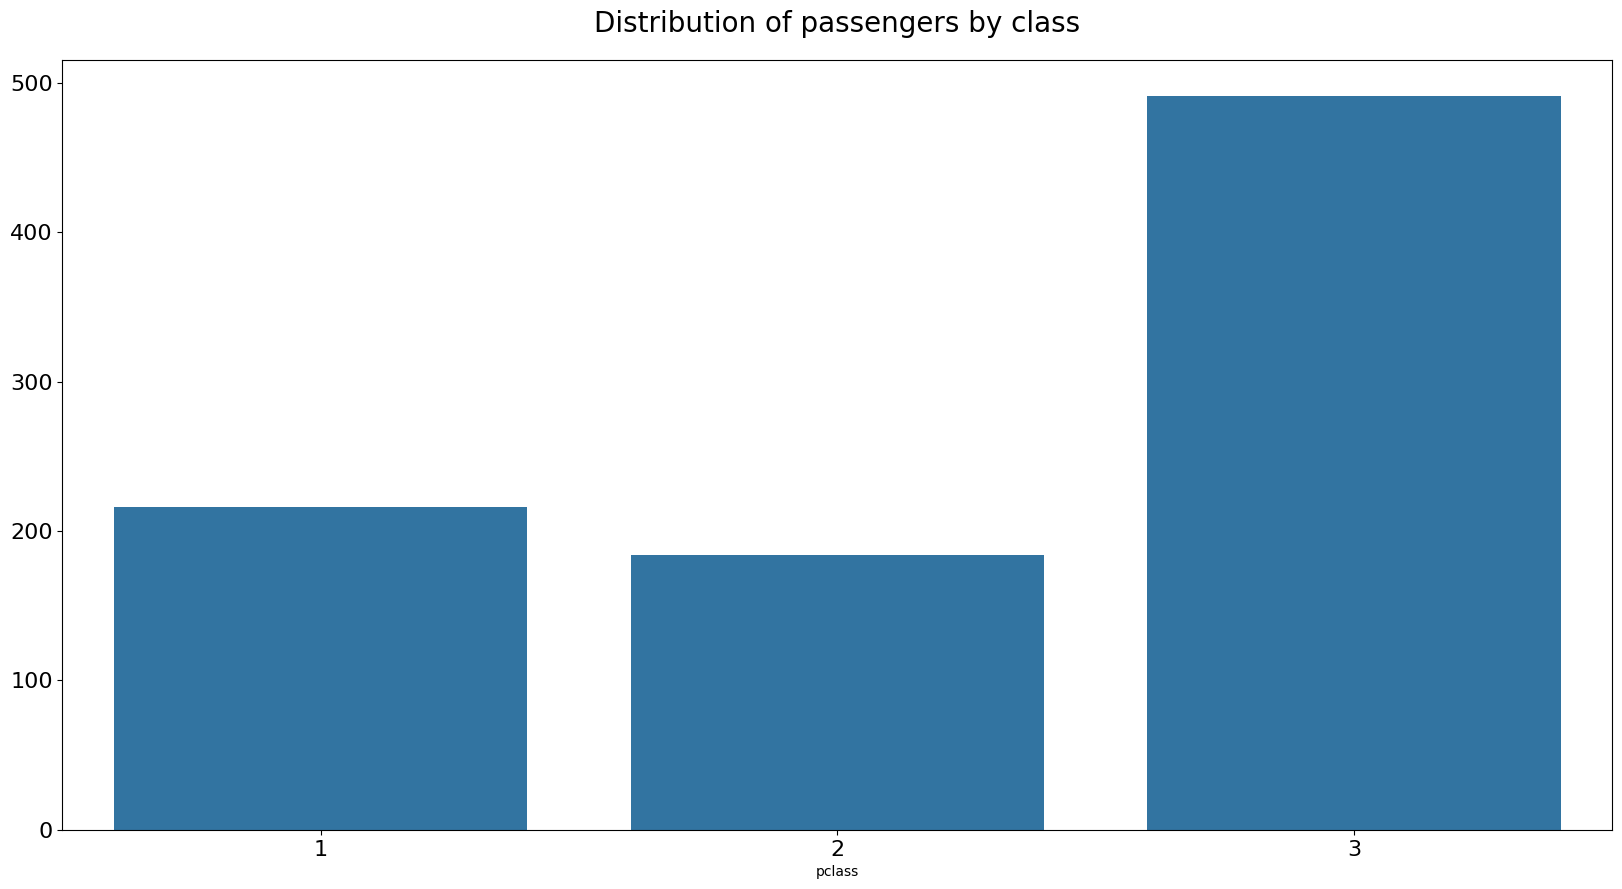

In [ ]:
# Task 3, part 1:

c = df['pclass'].value_counts().sort_values(ascending=False)


plt.figure(figsize = (20, 10))
ax = sns.barplot(y=c.values, x=c.index)
ax.set_ylabel('')
ax.set_title("Distribution of passengers by class", fontsize=20, pad=20)
plt.tick_params(labelsize=16)
plt.show()



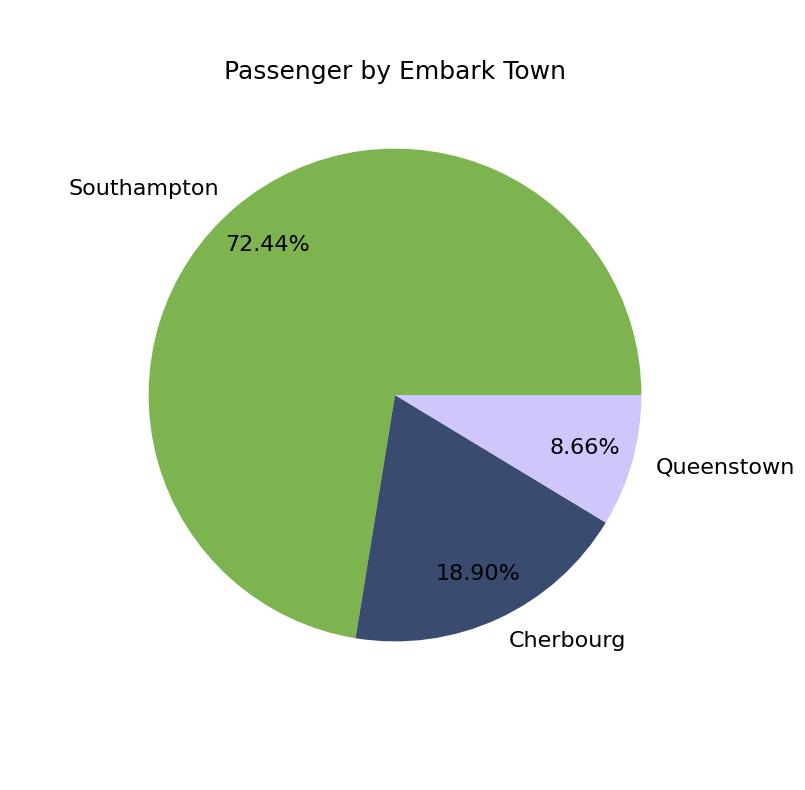

In [ ]:
# Your code her


# Task 3, part 2:
b = df.embark_town.value_counts()

plt.figure(figsize = (20, 10))
plt.pie(b,
        labels=b.index,
        autopct='%.2f%%',
        labeldistance=1.1,
        pctdistance=0.8,
        radius = 0.8,
        textprops={'fontsize': 16},
        colors=['#7DB450', '#394B6F', '#CFC6FB'])
plt.title("Passenger by Embark Town", fontsize=18, y=.9);


In [220]:
my_data = df.groupby('pclass')['survived'].mean()
fig = px.bar(my_data, x=my_data.index, y=my_data.values)
fig.show()

## Task 4. Group comparisons

1. Plot a **barplot with 95% CI** comparing mean `age` by `pclass`. Do older passengers tend to travel in higher classes?
2. Plot overlaid **histograms** of `fare` for survivors vs non-survivors (`hue='survived'`). What pattern do you see?
3. Run an **independent samples t-test** (Welch's): did male and female passengers pay different fares on average? State $H_0$, report t-statistic and p-value, interpret the result.

<Axes: xlabel='pclass', ylabel='age'>

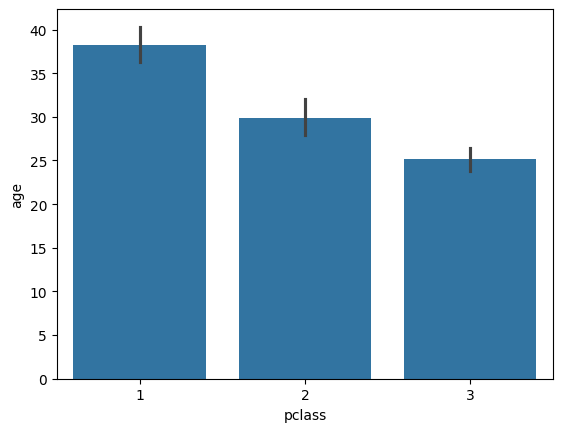

In [ ]:
# Your code here

#Your code here
#plt.figure(figsize=(18,10))
#sns.barplot(data = data_age_pclass, x="pclass", y = "age", errorbar=('ci', 95));

sns.barplot(data=df, x='pclass', y='age', errorbar=('ci', 95), order=[1, 2, 3])

## Task 5. ANOVA

1. Show mean `fare` by passenger class using `groupby`.
2. Run a **one-way ANOVA**: are fares significantly different across the three classes?
3. State $H_0$, report F-statistic and p-value. What can you *not* conclude from this result alone?

In [127]:
# Your code here


## Task 6. Relationships between variables

1. Plot a **scatter plot** of `age` vs `fare`, coloured by `survived`. Any visible pattern?
2. Compute and visualise a **correlation matrix heatmap** for numeric variables (`age`, `fare`, `pclass`, `sibsp`, `parch`, `survived`). Add significance stars.
3. Use **FacetGrid** to show the `age` distribution separately for each `pclass`. What differences do you notice?

In [128]:
# Your code here


## Task 7. Interactive visualisation with Plotly

1. Create an interactive **scatter plot** (`px.scatter`) of `age` vs `fare`, with `color='survived'`, `hover_data=['sex', 'pclass', 'embark_town']`.
2. Create an interactive **bar chart** (`px.bar`) of survival rate by `pclass` and `sex`. *(Hint: compute survival rate first with `groupby`, then pass to `px.bar`.)*
3. *(Bonus)* Create an interactive **box plot** (`px.box`) of `fare` by `pclass`, with `points='all'` and hover showing passenger name.

In [129]:
# Your code here
